# AutoGrow Analytics Notebook
## Complex Data Project: Growth Stage Analysis
### Advanced Analytics Pipeline: Isolation Forest → XGBoost + TimeSeriesSplit → SHAP

> **Three-Stage Intelligence Pipeline (Beyond Course)**
> 1. **Stage 1 (Isolation Forest):** Multivariate IoT anomaly detection before modelling
> 2. **Stage 2 (XGBoost + TimeSeriesSplit):** Gradient boosting with temporal cross-validation
> 3. **Stage 3 (SHAP):** Feature interpretability — *why* the model predicts each growth stage


## 1) Setup and Load 3 Tables
## 1.1 Install/Import Requirements
**Goal:** Ensure the notebook can run in the current kernel.

**What we do:** Auto-install missing packages, then import libraries.

**Method:** `importlib` for check and `pip install` for fallback.


In [1]:
# Standard library imports
import importlib       
import subprocess      
import sys            
import os             
from urllib.parse import quote_plus 


# Auto-installer function 
def ensure_package(pip_name, import_name=None):
    """
    Tries to import a package. If it's not found, installs it automatically via pip.
    
    - pip_name:    the name used when installing  (e.g. 'scikit-learn')
    - import_name: the name used when importing   (e.g. 'sklearn')
                   These differ for some packages, so we handle both.
    """
    module = import_name or pip_name  # Fall back to pip_name if no import_name given
    try:
        importlib.import_module(module)        # Try importing the package
    except ModuleNotFoundError:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pip_name])


# Auto-install all required packages if not already present 
ensure_package('numpy')                      
ensure_package('pandas')                      
ensure_package('matplotlib')                 
ensure_package('seaborn')                    
ensure_package('scikit-learn', 'sklearn')     
ensure_package('xgboost', 'xgboost')          
ensure_package('shap', 'shap')               
ensure_package('PyMySQL', 'pymysql')          
ensure_package('sqlalchemy', 'sqlalchemy')    
ensure_package('imbalanced-learn', 'imblearn') 


# Core data & plotting imports
import numpy as np                
import pandas as pd               
import matplotlib.pyplot as plt  
import seaborn as sns            
import pymysql                   


# Scikit-learn: evaluation metrics 
from sklearn.metrics import (
    f1_score,               
    classification_report,  
    confusion_matrix,     
    mean_absolute_error,   
    mean_squared_error,     
)

# Scikit-learn: pipeline & preprocessing 
from sklearn.pipeline import Pipeline          
from sklearn.impute import SimpleImputer       
from sklearn.preprocessing import StandardScaler  

# Scikit-learn: models 
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.ensemble import RandomForestClassifier, IsolationForest

# Scikit-learn: model selection 
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import LabelEncoder  
from sklearn.base import clone
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LinearRegression 


# Additional plotting utilities
import matplotlib.dates as mdates  
import matplotlib.patches as mpatches 


# Advanced ML libraries 
import xgboost as xgb  
import shap           
from imblearn.over_sampling import RandomOverSampler


# Global display settings 
sns.set_theme(style='whitegrid')           # Applies a clean white background to all seaborn plots
pd.set_option('display.max_columns', 200)  # Prevents pandas from hiding columns in wide DataFrames

print('Imports ready')  

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports ready


## 1.2 Connect DB and Load Tables
**Goal:** Load all required sources into 3 DataFrames.

**What we do:** Connect to MySQL and query 3 tables.

**Method:** `SHOW TABLES` + case-insensitive table matching + `pd.read_sql`.


In [2]:
import json
from urllib.parse import urlencode
from urllib.request import urlopen
from sqlalchemy import create_engine, text

# os.getenv() reads from environment variables, falling back to the hardcoded
# default if not set — keeps credentials out of the code in production
DB_HOST = os.getenv('DB_HOST', 'iot.cpe.ku.ac.th')
DB_USER = os.getenv('DB_USER', 'b6710545652')
DB_NAME = os.getenv('DB_NAME', 'b6710545652')
DB_PASS = os.getenv('DB_PASS', 'natcha.limsu@ku.th')

engine = create_engine(
    # quote_plus() encodes special characters in the password (e.g. '@' → '%40')
    # so the URL doesn't break when the password contains symbols
    f'mysql+pymysql://{DB_USER}:{quote_plus(DB_PASS)}@{DB_HOST}/{DB_NAME}?charset=utf8mb4'
)

with engine.connect() as conn:
    tables_df = pd.read_sql(text('SHOW TABLES'), conn)
    # SHOW TABLES returns a column named "Tables_in_<dbname>" which varies per DB,
    # so we grab whichever column it is dynamically instead of hardcoding the name
    table_col = tables_df.columns[0]
    all_tables = tables_df[table_col].astype(str).tolist()

def pick_table(name):
    low = {t.lower(): t for t in all_tables}
    if name.lower() in low:
        return low[name.lower()]
    # Partial match fallback — in case the actual table name has a prefix/suffix
    contains = [t for t in all_tables if name.lower() in t.lower()]
    if len(contains) == 1:
        return contains[0]
    raise ValueError(f'Cannot uniquely find table {name!r}. Available tables: {all_tables}')

autogrow_table = pick_table('Autogrow')
current_table  = pick_table('outdoor_weather_current')
history_table  = pick_table('outdoor_weather_history')

with engine.connect() as conn:
    df_autogrow                = pd.read_sql(text(f'SELECT * FROM `{autogrow_table}`'),  conn)
    df_outdoor_weather_current = pd.read_sql(text(f'SELECT * FROM `{current_table}`'),   conn)
    df_outdoor_weather_history = pd.read_sql(text(f'SELECT * FROM `{history_table}`'),   conn)

# Normalize column names so lookups are consistent regardless of how the DB named them
for _df in [df_autogrow, df_outdoor_weather_current, df_outdoor_weather_history]:
    _df.columns = [c.strip().lower() for c in _df.columns]

outdoor_lat = float(df_outdoor_weather_current['lat'].dropna().iloc[0]) if 'lat' in df_outdoor_weather_current.columns and df_outdoor_weather_current['lat'].notna().any() else 13.8476
outdoor_lon = float(df_outdoor_weather_current['lon'].dropna().iloc[0]) if 'lon' in df_outdoor_weather_current.columns and df_outdoor_weather_current['lon'].notna().any() else 100.5696

def fetch_outdoor_history_range(start_date, end_date):
    """Fetch an outdoor history window directly from the Open-Meteo archive API."""
    archive_url = 'https://archive-api.open-meteo.com/v1/archive?' + urlencode({
        'latitude': outdoor_lat,
        'longitude': outdoor_lon,
        'hourly': 'temperature_2m,relative_humidity_2m',
        'start_date': start_date.isoformat(),
        'end_date': end_date.isoformat(),
        'timezone': 'UTC',
    })
    try:
        with urlopen(archive_url, timeout=30) as resp:
            raw = json.loads(resp.read().decode('utf-8'))
    except Exception as exc:
        print(f'Could not fetch expanded outdoor history from Open-Meteo archive: {exc}')
        return None

    hourly = raw.get('hourly', {})
    payload = {
        'points': [
            {'ts': ts, 'temp': t, 'humidity': h}
            for ts, t, h in zip(hourly.get('time', []), hourly.get('temperature_2m', []), hourly.get('relative_humidity_2m', []))
        ]
    }

    points = payload.get('points', [])
    if not points:
        return None

    frame = pd.DataFrame(points)
    if 'temp' in frame.columns:
        frame = frame.rename(columns={'temp': 'temp_c'})
    if 'ts' in frame.columns:
        frame['ts'] = pd.to_datetime(frame['ts'], errors='coerce', utc=True).dt.tz_localize(None)
        frame = frame.dropna(subset=['ts']).sort_values('ts').reset_index(drop=True)
    return frame

print('Loaded tables:')
print(f'- {autogrow_table}:', df_autogrow.shape)
print(f'- {current_table}:', df_outdoor_weather_current.shape)
print(f'- {history_table}:', df_outdoor_weather_history.shape)


Loaded tables:
- Autogrow: (1569, 16)
- outdoor_weather_current: (98, 12)
- outdoor_weather_history: (192, 7)


## 1.3 Preview
**Goal:** Confirm schemas before exploration.

**What we do:** View top rows from all 3 data sources.

**Method:** `.head()` display.


In [3]:
display(df_autogrow.head())
display(df_outdoor_weather_current.head())
display(df_outdoor_weather_history.head())

,id,ts,stage,stage_name,spectrum,temp1,temp2,humidity,soil_pct,light_lux,vibration,pump_on,pump_status,light_hrs_today,harvest_eta_days,health_score
0,2,2026-04-11 17:07:39,0,Seedling,OFF,31.0,31.0,92.0,100.0,250.3,0,0,IDLE,3.18,14,80
1,3,2026-04-11 17:17:40,0,Seedling,OFF,31.0,31.0,90.0,100.0,225.9,0,0,IDLE,3.34,14,80
2,4,2026-04-11 17:27:41,0,Seedling,OFF,31.0,31.0,89.5,99.9,214.7,0,0,IDLE,3.51,14,80
3,5,2026-03-31 03:02:57,0,Seedling,OFF,45.0,0.0,45.0,45.0,45.0,0,0,OK,0.00,0,0
4,6,2026-03-31 03:04:02,0,Seedling,OFF,45.0,0.0,45.0,50.0,45.0,0,0,OK,0.00,0,0


,id,lat,lon,source,temp_c,humidity,wind_speed_mps,apparent_temp_c,sunrise_utc,sunset_utc,fetched_at,stored_at
0,1,13.7563,100.502,open-meteo,29.0,82.0,10.1,34.7,2026-04-19 23:02:00,2026-04-20 11:31:00,2026-04-20 17:52:48,2026-04-20 19:04:18
1,2,13.7563,100.502,open-meteo,29.0,82.0,10.1,34.7,2026-04-19 23:02:00,2026-04-20 11:31:00,2026-04-20 17:52:48,2026-04-20 19:21:50
2,3,13.7563,100.502,open-meteo,28.8,81.0,8.6,34.5,2026-04-19 23:02:00,2026-04-20 11:31:00,2026-04-20 19:22:37,2026-04-20 19:22:37
3,4,13.7563,100.502,open-meteo,32.5,64.0,8.9,39.3,2026-04-21 06:01:00,2026-04-21 18:32:00,2026-04-21 04:16:54,2026-04-21 04:24:50
4,5,13.7563,100.502,open-meteo,32.5,64.0,8.9,39.3,2026-04-20 23:01:00,2026-04-21 11:32:00,2026-04-21 04:18:51,2026-04-21 04:24:50


,id,lat,lon,source,ts,temp_c,humidity
0,1,13.7563,100.502,open-meteo,2026-04-13 00:00:00,28.3,89.0
1,2,13.7563,100.502,open-meteo,2026-04-13 01:00:00,30.0,76.0
2,3,13.7563,100.502,open-meteo,2026-04-13 02:00:00,31.8,62.0
3,4,13.7563,100.502,open-meteo,2026-04-13 03:00:00,33.3,57.0
4,5,13.7563,100.502,open-meteo,2026-04-13 04:00:00,34.9,52.0


## 2) Complex Data Exploration
## 2.1 Detect Key Columns & Parse Timestamps
**Goal:** Standardize all three DataFrames so they share consistent column names and timestamps, ready for merging and modeling

**Method:** Heuristic column detection using priority name lists + pd.to_datetime for timestamp parsing.


**Processes:** 
- **Column detection**:  first_existing() returns the first matching candidate name found in the DataFrame, handling schema differences
- **Timestamp detection**:  detect_datetime_col() picks the column with the highest datetime parse success rate
- **Timestamp standardization**:  converts all timestamps to UTC then strips timezone info for consistent comparison
- **Hour bucketing**:  floors timestamps to the nearest hour, creating a shared merge key for indoor and outdoor data



In [4]:
def first_existing(columns, candidates):
    colset = set(columns)
    for c in candidates:
        if c in colset:
            return c
    return None  # Returns None if none of the candidates exist


def detect_datetime_col(df):
    # Filter columns whose names suggest they contain datetime values
    candidates = [c for c in df.columns if any(k in c for k in ['time', 'date', 'created', 'ts'])]
    best, score = None, -1
    for c in candidates:
        parsed = pd.to_datetime(df[c], errors='coerce', utc=True)
        # Score each candidate by what fraction of its values successfully parsed as datetime
        # The column with the highest success rate wins
        s = parsed.notna().mean()
        if s > score:
            best, score = c, s
    return best

ag = df_autogrow.copy()
wh = df_outdoor_weather_history.copy()
wc = df_outdoor_weather_current.copy()

col_ts_ag = detect_datetime_col(ag)
col_ts_wh = detect_datetime_col(wh)
col_ts_wc = detect_datetime_col(wc)

# first_existing() tries each candidate name in order and returns the first one found
# — handles different naming conventions across DB schemas
col_stage_name  = first_existing(ag.columns, ['stage_name'])
col_stage       = first_existing(ag.columns, ['stage'])
col_temp_in     = first_existing(ag.columns, ['temp1', 'temperature', 'temp'])
col_hum_in      = first_existing(ag.columns, ['humidity', 'humidity1', 'rh'])
col_soil        = first_existing(ag.columns, ['soil_pct', 'soil', 'soil_moisture'])
col_light_lux   = first_existing(ag.columns, ['light_lux', 'lux', 'light'])
col_light_hrs   = first_existing(ag.columns, ['light_hrs_today', 'light_hours_today', 'light_hrs'])
col_health      = first_existing(ag.columns, ['health_score', 'health'])
col_vibration   = first_existing(ag.columns, ['vibration'])
col_pump_status = first_existing(ag.columns, ['pump_status', 'pump_state', 'pump'])

col_temp_out = first_existing(wh.columns, ['temp_c', 'temperature_2m', 'temperature', 'temp'])
col_hum_out  = first_existing(wh.columns, ['humidity', 'relative_humidity_2m', 'humidity_2m'])

# Fixed names for outdoor features after merging — used consistently downstream
col_temp_out_feat = 'outdoor_temp'
col_hum_out_feat  = 'outdoor_humidity'

if col_ts_ag is None or col_ts_wh is None:
    raise ValueError('Cannot detect timestamp columns in Autogrow or outdoor_weather_history.')

# Parse timestamps: utc=True standardizes timezone, tz_localize(None) strips it
# so all three DataFrames use naive (timezone-free) datetimes for easy comparison
ag['ts'] = pd.to_datetime(ag[col_ts_ag], errors='coerce', utc=True).dt.tz_localize(None)
wh['ts'] = pd.to_datetime(wh[col_ts_wh], errors='coerce', utc=True).dt.tz_localize(None)
if col_ts_wc:
    wc['ts'] = pd.to_datetime(wc[col_ts_wc], errors='coerce', utc=True).dt.tz_localize(None)

ag = ag.dropna(subset=['ts']).sort_values('ts').reset_index(drop=True)
wh = wh.dropna(subset=['ts']).sort_values('ts').reset_index(drop=True)

sensor_start_date = ag['ts'].min().date()
sensor_end_date = ag['ts'].max().date()
expanded_wh = fetch_outdoor_history_range(sensor_start_date, sensor_end_date)
if expanded_wh is not None:
    wh = expanded_wh
    df_outdoor_weather_history = expanded_wh.copy()
    print(f'Weather history fetch successful: {len(wh)} rows from {wh["ts"].min()} to {wh["ts"].max()}')
    display(wh.head(10))
else:
    print('Weather history fetch failed; continuing with the loaded database table.')

print('Requested outdoor history window to match sensors:', sensor_start_date, '->', sensor_end_date)

# Floor timestamps to the nearest hour so indoor and outdoor data
# can be joined on a shared hourly key later in the pipeline
ag['hour_bucket'] = ag['ts'].dt.floor('h')
wh['hour_bucket'] = wh['ts'].dt.floor('h')

Weather history fetch successful: 456 rows from 2026-03-31 00:00:00 to 2026-04-18 23:00:00


,ts,temp_c,humidity
0,2026-03-31 00:00:00,27.5,77
1,2026-03-31 01:00:00,29.1,67
2,2026-03-31 02:00:00,30.9,59
3,2026-03-31 03:00:00,32.4,53
4,2026-03-31 04:00:00,33.8,48
5,2026-03-31 05:00:00,35.0,42
6,2026-03-31 06:00:00,35.2,41
7,2026-03-31 07:00:00,35.2,40
8,2026-03-31 08:00:00,34.9,41
9,2026-03-31 09:00:00,34.3,43


Requested outdoor history window to match sensors: 2026-03-31 -> 2026-04-18


## 2.2 Column Detection Result
**Goal:** Verify that column detection and timestamp parsing worked correctly before proceeding.

**Method:** Plain print statements inspecting detected column names and data time ranges.

**Processes:** 
- **Column audit:** prints every detected sensor/target column so any None values (missed detections) are immediately visible
- **Time range check:** confirms the date coverage and row count of both indoor and outdoor datasets


In [5]:
# Sanity check — confirms which columns were auto-detected before any modeling begins
print('Detected columns summary:')
print('  - stage_name:', col_stage_name)
print('  - stage:', col_stage)
print('  - temp_in:', col_temp_in)
print('  - temp_out:', col_temp_out)
print('  - hum_in:', col_hum_in)
print('  - hum_out:', col_hum_out)
print('  - soil:', col_soil)
print('  - light:', col_light_lux)
print('  - health:', col_health)
print('  - vibration:', col_vibration)
print('  - pump_status:', col_pump_status)
print('  - Time range from indoor sensors (AutoGrow table):', ag['ts'].min(), '->', ag['ts'].max(), '| rows:', len(ag))
print('  - Time range from API (weather history table):', wh['ts'].min(), '->', wh['ts'].max(), '| rows:', len(wh))

Detected columns summary:
  - stage_name: stage_name
  - stage: stage
  - temp_in: temp1
  - temp_out: temp_c
  - hum_in: humidity
  - hum_out: humidity
  - soil: soil_pct
  - light: light_lux
  - health: health_score
  - vibration: vibration
  - pump_status: pump_status
  - Time range from indoor sensors (AutoGrow table): 2026-03-31 03:02:57 -> 2026-04-18 13:18:29 | rows: 1569
  - Time range from API (weather history table): 2026-03-31 00:00:00 -> 2026-04-18 23:00:00 | rows: 456


## 2.3 Time-Series Visualization

**Goal:**  Visualize how each indoor sensor reading changes over the full duration of the experiment.

**Method:** One line chart per sensor stacked vertically with a shared time axis, annotated with stage-transition markers.


**Processes:** 
- **Subplots:** one panel per detected sensor column, dynamically sized based on how many columns exist
- **Stage markers:** detects rows where the growth stage changes and draws a dashed vertical line across all panels at that timestamp
- **Axis formatting:** x-axis ticks every 2 days, rotated for readability

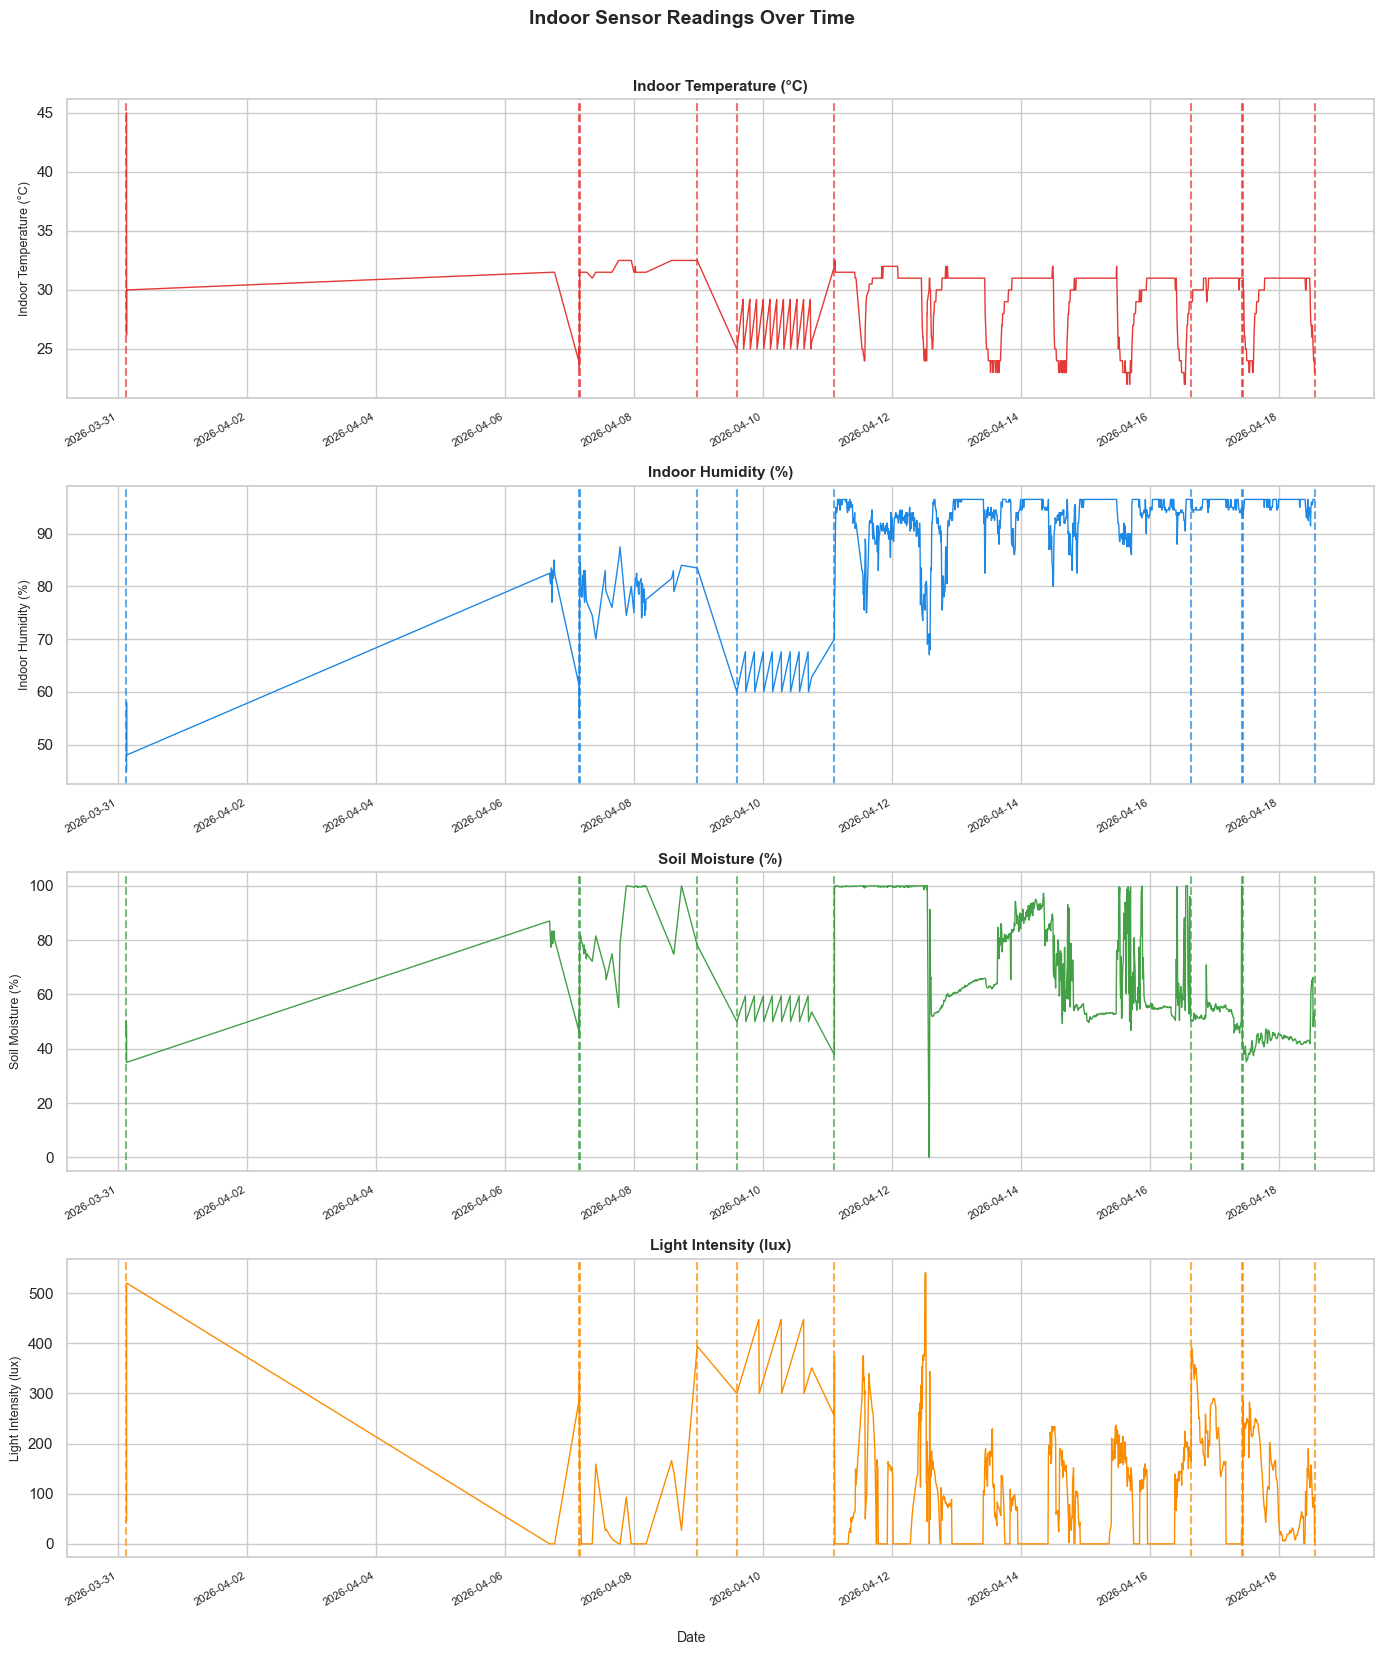

In [6]:
plot_cols = [c for c in [col_temp_in, col_hum_in, col_soil, col_light_lux] if c is not None]

label_map = {
    col_temp_in:    "Indoor Temperature (°C)",
    col_hum_in:     "Indoor Humidity (%)",
    col_soil:       "Soil Moisture (%)",
    col_light_lux:  "Light Intensity (lux)",
}

color_map = {
    col_temp_in:   "#E53935",
    col_hum_in:    "#1E88E5",
    col_soil:      "#43A047",
    col_light_lux: "#FB8C00",
}

if plot_cols:
    # Creates one subplot per sensor, all sharing the same x-axis (time)
    fig, axes = plt.subplots(len(plot_cols), 1, figsize=(14, 4 * len(plot_cols)), sharex=True)
    if len(plot_cols) == 1:
        axes = [axes]  # Ensure axes is always a list for consistent iteration below

    fig.suptitle("Indoor Sensor Readings Over Time", fontsize=14, fontweight="bold", y=1.01)

    stage_col_for_marker = col_stage_name if col_stage_name else col_stage
    if stage_col_for_marker:
        # Detect rows where the stage value changes — used to draw vertical stage-transition lines
        stage_changes = ag[stage_col_for_marker].astype(str).ne(ag[stage_col_for_marker].astype(str).shift(1))

    for ax, c in zip(axes, plot_cols):
        readable = label_map.get(c, c.replace("_", " ").title())
        color = color_map.get(c, "#546E7A")
        ax.plot(ag["ts"], ag[c], linewidth=1, color=color)
        ax.set_title(readable, fontsize=11, fontweight="bold", pad=6)
        ax.set_ylabel(readable, fontsize=9)
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
        ax.tick_params(axis="x", labelbottom=True, labelrotation=30, labelsize=8)
        plt.setp(ax.xaxis.get_majorticklabels(), ha="right")
        if stage_changes is not None:
            # Draw a dashed vertical line at every point the plant transitions to a new stage
            for t in ag.loc[stage_changes, "ts"]:
                ax.axvline(t, linestyle="--", alpha=0.7, linewidth=1.5, color=color)

    fig.text(0.5, -0.01, "Date", ha="center", fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("No sensor columns found for time-series plotting.")

## 2.4a Stage Distribution and Class Imbalance

**Goal:** Quantify how many data points exist per growth stage to identify class imbalance before modeling.

**Method:** Bar chart of stage counts, ordered biologically and restricted to true growth stages.

**Processes:**
- **Harvested exclusion:** filters out "harvested" rows because it is a termination event, not a growth stage the model should predict
- **Biological ordering:** sorts bars as seedling → vegetative → bloom instead of alphabetically for intuitive readability
- **Count annotation:** displays the exact row count on top of each bar for quick imbalance assessment

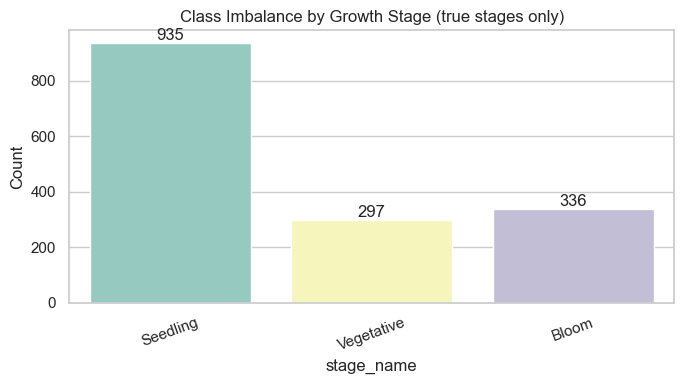

Stage counts (true stages only):
stage_name
Seedling      935
Vegetative    297
Bloom         336
Name: count, dtype: int64


In [7]:
stage_col = col_stage_name if col_stage_name else col_stage
if stage_col is None:
    print('No stage column found; skip stage-based plots.')
else:
    stage_values = ag[stage_col].astype(str).str.strip()
    # Exclude 'harvested' because it is a termination event, not a stage we want to model
    stage_values = stage_values[stage_values.str.lower() != 'harvested']
    counts = stage_values.value_counts()

    if counts.empty:
        print('No non-harvested stages found; skip stage-based plots.')
    else:
        # Force biological order (seedling → vegetative → bloom) instead of alphabetical
        stage_rank = {'seedling': 0, 'vegetative': 1, 'bloom': 2}
        ordered_labels = sorted(
            counts.index,
            key=lambda s: (stage_rank.get(str(s).strip().lower(), 99), str(s))
        )
        counts = counts.reindex(ordered_labels)

        plt.figure(figsize=(7, 4))
        sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="Set3", legend=False)
        plt.title('Class Imbalance by Growth Stage (true stages only)')
        plt.ylabel('Count')
        plt.xlabel(stage_col)
        plt.xticks(rotation=20)
        # Annotate exact count on top of each bar
        for i, v in enumerate(counts.values):
            plt.text(i, v, str(v), ha='center', va='bottom')
        plt.tight_layout()
        plt.show()

        print('Stage counts (true stages only):')
        print(counts)

## 2.4b Sensor Distribution by Growth Stage

**Goal:** Show how each sensor reading is distributed within each growth stage to reveal stage-specific patterns.

**Method:** Horizontal box plots with one chart per sensor, grouped by growth stage.

**Processes:**
- **Per-sensor plots:** iterates over each detected sensor column and produces a separate box plot
- **Stage grouping:** y-axis is the growth stage, x-axis is the sensor value — making it easy to compare medians and spreads across stages

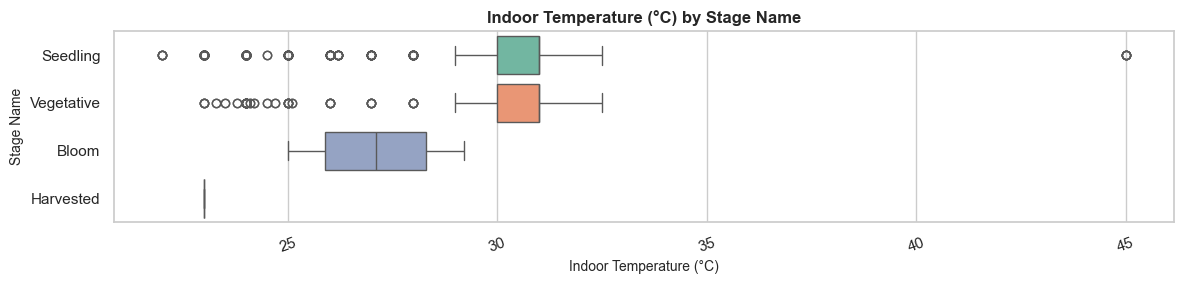

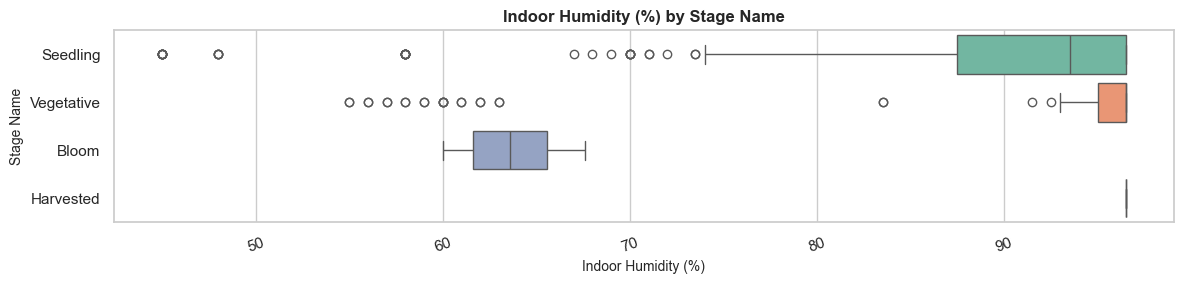

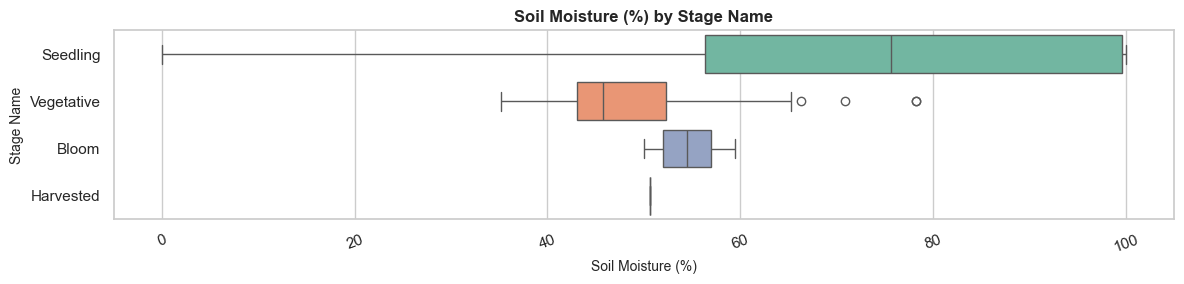

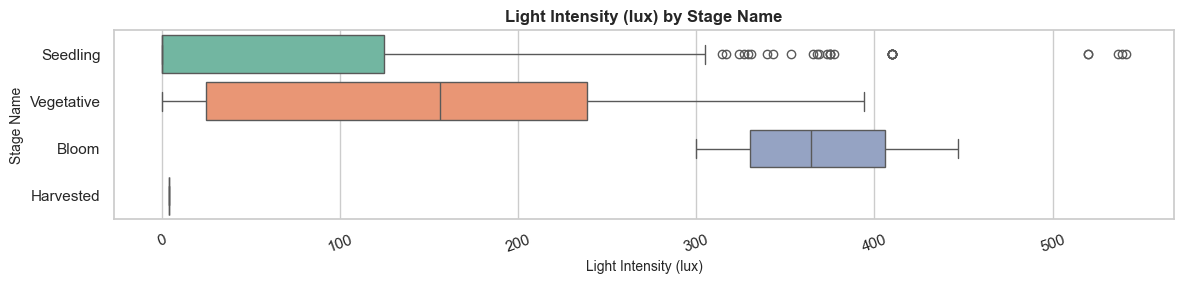

In [8]:
stage_col = col_stage_name if col_stage_name else col_stage

label_map = {
    col_temp_in:   "Indoor Temperature (°C)",
    col_hum_in:    "Indoor Humidity (%)",
    col_soil:      "Soil Moisture (%)",
    col_light_lux: "Light Intensity (lux)",
}

# Convert column name to readable title (e.g. "stage_name" → "Stage Name")
stage_label = stage_col.replace("_", " ").title() if stage_col else "Growth Stage"

if stage_col is not None:
    dist_cols = [c for c in [col_temp_in, col_hum_in, col_soil, col_light_lux] if c is not None]
    # One box plot per sensor — shows how each sensor's distribution differs across stages
    for c in dist_cols:
        readable = label_map.get(c, c.replace("_", " ").title())
        plt.figure(figsize=(12, 3))
        sns.boxplot(data=ag, x=c, y=stage_col, hue=stage_col, palette="Set2", legend=False)
        plt.title(f"{readable} by {stage_label}", fontsize=12, fontweight="bold")
        plt.xlabel(readable, fontsize=10)
        plt.ylabel(stage_label, fontsize=10)
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()

## 2.5a Indoor vs Outdoor Data Merging

**Goal:** Combine indoor and outdoor readings into a single hourly table for direct comparison.

**Method:** Aggregate both datasets to hourly means, then inner join on `hour_bucket`.

**Processes:**
- **Hourly aggregation:** averages all readings within each hour to align the two datasets on the same time resolution
- **Conditional aggregation:** only includes columns that were successfully detected — avoids errors if a sensor is missing
- **Inner join:** keeps only hours where both indoor and outdoor data exist, ensuring no NaNs from mismatched timestamps

In [9]:
# Build hourly averages for indoor sensors — only includes columns that were detected
indoor_agg = {}
if col_temp_in:
    indoor_agg['indoor_temp'] = (col_temp_in, 'mean')
if col_hum_in:
    indoor_agg['indoor_humidity'] = (col_hum_in, 'mean')
ag_hour = ag.groupby('hour_bucket').agg(**indoor_agg).reset_index() if indoor_agg else ag[['hour_bucket']].drop_duplicates()

# Same for outdoor — renames columns to fixed names (outdoor_temp, outdoor_humidity)
# so downstream code doesn't need to worry about the original DB column names
outdoor_agg = {}
if col_temp_out:
    outdoor_agg[col_temp_out_feat] = (col_temp_out, 'mean')
if col_hum_out:
    outdoor_agg[col_hum_out_feat] = (col_hum_out, 'mean')
wh_hour = wh.groupby('hour_bucket').agg(**outdoor_agg).reset_index() if outdoor_agg else wh[['hour_bucket']].drop_duplicates()

# Inner join on hour_bucket — only keeps hours where both indoor and outdoor data exist
merged_io = ag_hour.merge(wh_hour, on='hour_bucket', how='inner')
print('Indoor/outdoor merged rows:', len(merged_io))
display(merged_io.head())

Indoor/outdoor merged rows: 231


,hour_bucket,indoor_temp,indoor_humidity,outdoor_temp,outdoor_humidity
0,2026-03-31 03:00:00,32.980000,50.800000,32.4,53.0
1,2026-04-06 16:00:00,31.500000,81.333333,29.8,75.0
2,2026-04-06 17:00:00,31.500000,81.416667,29.5,76.0
3,2026-04-06 18:00:00,31.500000,83.750000,29.5,76.0
4,2026-04-07 03:00:00,24.881818,60.909091,33.5,45.0


## 2.5b Indoor vs Outdoor Comparison Plot

**Goal:** Visually assess how much outdoor weather conditions influence the indoor growing enclosure.

**Method:** Overlaid line charts comparing indoor and outdoor temperature and humidity over time.

**Processes:**
- **Two separate charts:** one for temperature, one for humidity — plotted on the same time axis for direct comparison
- **Guard conditions:** skips plotting if either column is missing or the merged table is empty

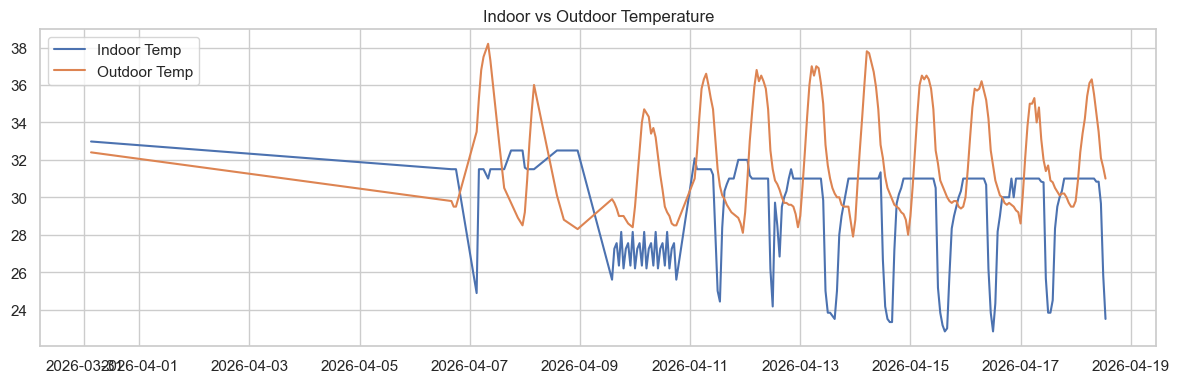

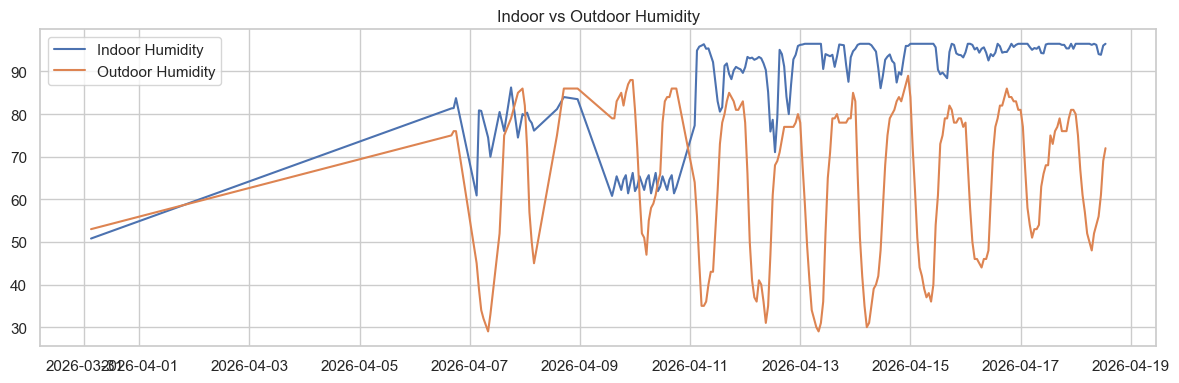

In [10]:
# Guard checks ensure we don't plot if columns are missing or the merge produced no rows
if 'indoor_temp' in merged_io.columns and col_temp_out_feat in merged_io.columns and not merged_io.empty:
    plt.figure(figsize=(12, 4))
    plt.plot(merged_io['hour_bucket'], merged_io['indoor_temp'], label='Indoor Temp')
    plt.plot(merged_io['hour_bucket'], merged_io[col_temp_out_feat], label='Outdoor Temp')
    plt.title('Indoor vs Outdoor Temperature')
    plt.legend()
    plt.tight_layout()
    plt.show()

if 'indoor_humidity' in merged_io.columns and col_hum_out_feat in merged_io.columns and not merged_io.empty:
    plt.figure(figsize=(12, 4))
    plt.plot(merged_io['hour_bucket'], merged_io['indoor_humidity'], label='Indoor Humidity')
    plt.plot(merged_io['hour_bucket'], merged_io[col_hum_out_feat], label='Outdoor Humidity')
    plt.title('Indoor vs Outdoor Humidity')
    plt.legend()
    plt.tight_layout()
    plt.show()

## 2.6 Correlation Heatmap

**Goal:** Identify linear relationships between all numeric sensor readings.

**Method:** Pearson correlation matrix visualized as a heatmap.

**Processes:**
- **Auto column selection:** only numeric columns are included, avoiding errors from text or datetime fields
- **Color anchoring:** `center=0` maps zero correlation to white, making positive (red) and negative (blue) relationships immediately clear

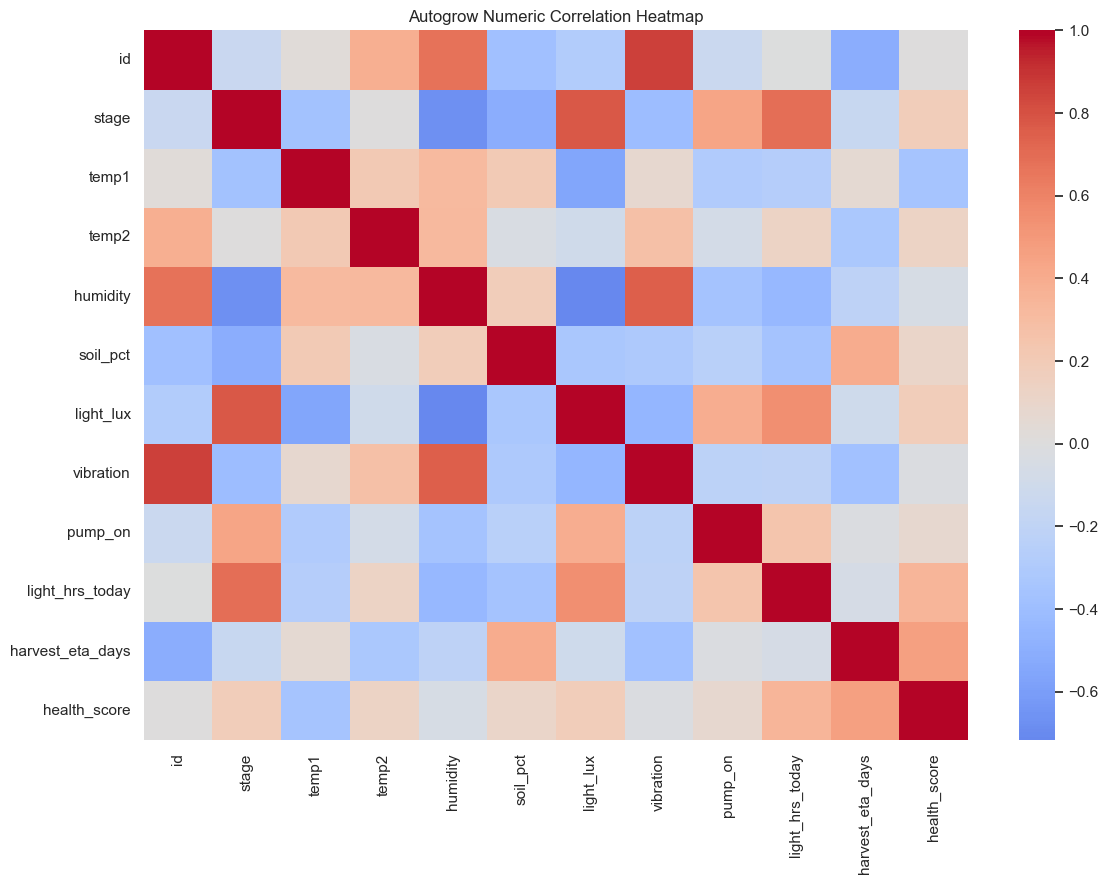

In [11]:
# Automatically selects only numeric columns — skips text/datetime columns that can't be correlated
numeric_cols = ag.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) > 1:
    plt.figure(figsize=(12, 9))
    # center=0 ensures the colormap is anchored at zero — red = positive, blue = negative correlation
    sns.heatmap(ag[numeric_cols].corr(), cmap='coolwarm', center=0)
    plt.title('Autogrow Numeric Correlation Heatmap')
    plt.tight_layout()
    plt.show()

## 3) Complex Data Pre-Processing Pipeline
Pipeline steps are intentionally separated for traceable outputs.


## 3.1 Timestamp Alignment Check

**Goal:** Verify that indoor and outdoor datasets overlap in time before merging.

**Method:** Print row counts, unique hour buckets, and date ranges for both DataFrames.

**Processes:**
- **Row vs bucket count:** if hour buckets are far fewer than rows, multiple readings exist per hour — expected behavior
- **Time range overlap:** if `ag` and `wh` date ranges don't overlap, the merge will produce no usable rows

In [12]:
# Confirms row counts, hourly coverage, and time ranges before merging
print('Autogrow rows:', len(ag), '| Hour buckets:', ag['hour_bucket'].nunique())
print('Weather history rows:', len(wh), '| Hour buckets:', wh['hour_bucket'].nunique())
print('Autogrow start/end:', ag['ts'].min(), '->', ag['ts'].max())
print('Weather start/end:', wh['ts'].min(), '->', wh['ts'].max())

Autogrow rows: 1569 | Hour buckets: 231
Weather history rows: 456 | Hour buckets: 456
Autogrow start/end: 2026-03-31 03:02:57 -> 2026-04-18 13:18:29
Weather start/end: 2026-03-31 00:00:00 -> 2026-04-18 23:00:00


### 3.2 Outlier Detection (IQR)
**Goal:** Detect suspicious sensor points likely to distort models.

**Method:** Compute IQR thresholds for key columns.

**Processes:**
- Compute the first and third quartiles for each monitored column.
- Derive Tukey fences with `Q1 - 1.5*IQR` and `Q3 + 1.5*IQR`.
- Use those bounds to mark values that are unusually far from the bulk of the data.


In [13]:
prep = ag.copy()
outlier_cols = [c for c in [col_soil, col_temp_in] if c is not None]
outlier_stats = []

for c in outlier_cols:
    s = pd.to_numeric(prep[c], errors='coerce')
    # IQR method: anything below Q1 - 1.5×IQR or above Q3 + 1.5×IQR is flagged as an outlier
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (s < low) | (s > high)
    outlier_stats.append({
        'column': c,
        'q1': q1,
        'q3': q3,
        'low': low,
        'high': high,
        'outlier_count': int(mask.sum())
    })

# Display stats only — rows are not removed yet, that happens in the next step
outlier_stats_df = pd.DataFrame(outlier_stats)
display(outlier_stats_df)

,column,q1,q3,low,high,outlier_count
0,soil_pct,52.5,81.8,8.55,125.75,4
1,temp1,27.1,31.0,21.25,36.85,6


### 3.3 Outlier Handling Result
**Goal:** Remove strong outliers and report the impact on row counts.

**Method:** Apply IQR-based filtering to the monitored sensor columns.

**Processes:**
- Compute IQR bounds for each monitored column.
- Keep only rows that stay within the accepted thresholds.
- Compare the row count before and after filtering.


In [14]:
keep = pd.Series(True, index=prep.index)
for c in outlier_cols:
    s = pd.to_numeric(prep[c], errors='coerce')
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    keep &= s.between(low, high) | s.isna()

prep_iqr = prep[keep].copy()
print('Rows before IQR filter:', len(prep))
print('Rows after IQR filter :', len(prep_iqr))
print('Rows removed          :', len(prep) - len(prep_iqr))


Rows before IQR filter: 1569
Rows after IQR filter : 1559
Rows removed          : 10


### 3.3b Advanced Outlier Detection: Isolation Forest (Stage 1 — Beyond Course)
**Goal:** Complement IQR filtering with an unsupervised anomaly detector.

**Method:** Apply `IsolationForest` to the numeric sensor matrix after imputation.

**Processes:**
- Fit `IsolationForest(contamination=0.02, random_state=42)` on the sensor features.
- Flag rows that look anomalous across multiple columns at once.
- Keep the inlier rows for `prep_clean` and later modeling steps.


Isolation Forest | Features: ['soil_pct', 'temp1', 'humidity', 'light_lux']
  Total rows      : 1559
  IF Outliers     : 32 (2.05%)
  Clean inliers   : 1527


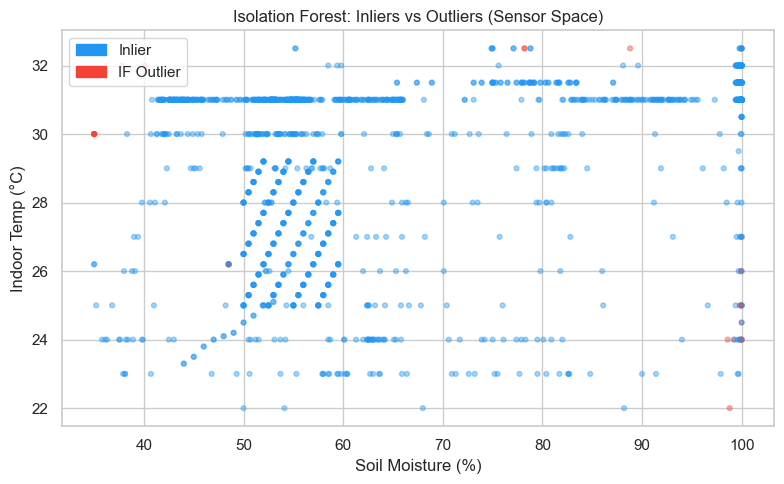


Rows after IQR + IF pipeline: 1527 (removed 32 additional rows by IF)


In [15]:
iso_cols = [c for c in [col_soil, col_temp_in, col_hum_in, col_light_lux]
            if c is not None and c in prep_iqr.columns]

if len(iso_cols) >= 2:
    iso_input = prep_iqr[iso_cols].copy()
    iso_imputer = SimpleImputer(strategy='median')
    iso_input_imp = iso_imputer.fit_transform(iso_input)

    iso_forest = IsolationForest(contamination=0.02, random_state=42, n_jobs=-1)
    iso_labels = iso_forest.fit_predict(iso_input_imp)  # 1=inlier, -1=outlier
    prep_iqr['isolation_flag'] = iso_labels

    n_outliers = (iso_labels == -1).sum()
    n_total = len(iso_labels)
    print(f'Isolation Forest | Features: {iso_cols}')
    print(f'  Total rows      : {n_total}')
    print(f'  IF Outliers     : {n_outliers} ({100*n_outliers/n_total:.2f}%)')
    print(f'  Clean inliers   : {n_total - n_outliers}')

    # Visualise: IQR-only vs IQR+IF
    colors = ['#2196F3' if v == 1 else '#F44336' for v in iso_labels]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(iso_input_imp[:, 0], iso_input_imp[:, 1],
               c=colors, alpha=0.4, s=12)
    ax.legend(handles=[
        mpatches.Patch(color='#2196F3', label='Inlier'),
        mpatches.Patch(color='#F44336', label='IF Outlier')
    ])
    label_map = {
        col_soil:      'Soil Moisture (%)',
        col_temp_in:   'Indoor Temp (°C)',
        col_hum_in:    'Indoor Humidity (%)',
        col_light_lux: 'Light Intensity (lux)',
    }
    ax.set_xlabel(label_map.get(iso_cols[0], iso_cols[0].replace('_', ' ').title()))
    ax.set_ylabel(label_map.get(iso_cols[1], iso_cols[1].replace('_', ' ').title()))
    ax.set_title('Isolation Forest: Inliers vs Outliers (Sensor Space)')
    plt.tight_layout()
    plt.show()

    prep_clean = prep_iqr[prep_iqr['isolation_flag'] == 1].drop(columns=['isolation_flag']).copy()
    print(f'\nRows after IQR + IF pipeline: {len(prep_clean)} '
          f'(removed {len(prep_iqr) - len(prep_clean)} additional rows by IF)')
else:
    print('Not enough sensor columns for Isolation Forest; using IQR-only filtered data.')
    prep_clean = prep_iqr.copy()


### 3.4 Missing-Value Audit
**Goal:** Make missingness explicit before imputation and modeling.

**Method:** Summarize null counts column by column after outlier filtering.

**Processes:**
- Count missing values for each feature.
- Print the null summary so weak columns are visible early.
- Use the audit to decide how much imputation the model will need.


In [16]:
# Null audit after full cleaning pipeline (IQR + Isolation Forest)
nulls_after_clean = prep_clean.isna().sum().sort_values(ascending=False)
display(nulls_after_clean[nulls_after_clean > 0].to_frame('null_count'))
print(f'Rows in prep_clean: {len(prep_clean)}')


,null_count


Rows in prep_clean: 1527


### 3.5 Multi-Source Fusion
**Goal:** Combine indoor and outdoor context into one modeling table.

**Method:** Join `prep_iqr` with hourly outdoor weather and daylight-hour signals.

**Processes:**
- Align indoor rows to the nearest hourly weather bucket.
- Merge weather history and daylight context into the same frame.
- Keep the fused table ready for feature engineering and modeling.


In [17]:
feat = prep_clean.copy()

outdoor_agg = {}
if col_temp_out:
    outdoor_agg[col_temp_out_feat] = (col_temp_out, 'mean')
if col_hum_out:
    outdoor_agg[col_hum_out_feat] = (col_hum_out, 'mean')

if outdoor_agg:
    wh_hourly_feat = wh.groupby('hour_bucket').agg(**outdoor_agg).reset_index()
    feat = feat.merge(wh_hourly_feat, on='hour_bucket', how='left')
else:
    feat[col_temp_out_feat] = np.nan
    feat[col_hum_out_feat] = np.nan

col_sunrise = first_existing(wc.columns, ['sunrise_utc', 'sunrise'])
col_sunset = first_existing(wc.columns, ['sunset_utc', 'sunset'])
if col_sunrise and col_sunset:
    wc_tmp = wc.copy()
    wc_tmp['sunrise_dt'] = pd.to_datetime(wc_tmp[col_sunrise], errors='coerce', utc=True).dt.tz_localize(None)
    wc_tmp['sunset_dt'] = pd.to_datetime(wc_tmp[col_sunset], errors='coerce', utc=True).dt.tz_localize(None)
    wc_tmp['daylight_hours'] = (wc_tmp['sunset_dt'] - wc_tmp['sunrise_dt']).dt.total_seconds() / 3600
    if 'ts' in wc_tmp.columns and wc_tmp['ts'].notna().any():
        wc_tmp['date'] = wc_tmp['ts'].dt.date
    else:
        wc_tmp['date'] = wc_tmp['sunrise_dt'].dt.date
    daylight_df = wc_tmp.groupby('date', as_index=False)['daylight_hours'].mean()
    feat['date'] = feat['ts'].dt.date
    feat = feat.merge(daylight_df, on='date', how='left')
else:
    feat['daylight_hours'] = np.nan

print('Feature table shape after merge:', feat.shape)
display(feat.head())


Feature table shape after merge: (1527, 21)


,id,ts,stage,stage_name,spectrum,temp1,temp2,humidity,soil_pct,light_lux,vibration,pump_on,pump_status,light_hrs_today,harvest_eta_days,health_score,hour_bucket,outdoor_temp,outdoor_humidity,date,daylight_hours
0,10,2026-03-31 03:13:40,0,Seedling,OFF,26.2,0.0,58.0,48.5,410.0,0,0,OK,0.0,0,0,2026-03-31 03:00:00,32.4,53.0,2026-03-31,NaN
1,176,2026-03-31 03:13:40,0,Seedling,,26.2,26.2,58.0,48.5,410.0,0,0,OK,0.0,0,0,2026-03-31 03:00:00,32.4,53.0,2026-03-31,NaN
2,11,2026-03-31 03:13:46,0,Seedling,OFF,26.2,0.0,58.0,35.0,410.0,0,0,OK,0.0,0,0,2026-03-31 03:00:00,32.4,53.0,2026-03-31,NaN
3,177,2026-03-31 03:13:46,0,Seedling,,26.2,26.2,58.0,35.0,410.0,0,0,OK,0.0,0,0,2026-03-31 03:00:00,32.4,53.0,2026-03-31,NaN
4,181,2026-04-06 16:39:46,0,Seedling,,31.5,31.5,82.5,87.1,0.0,0,0,OK,0.0,0,0,2026-04-06 16:00:00,29.8,75.0,2026-04-06,NaN


### 3.6 Feature Engineering
**Goal:** Create predictive features from the existing time series without introducing label leakage.

**Method:** Build leakage-safe sensor transforms, multi-scale lag/rolling temporal context, and cyclical hour encoding.

**Processes:**
- Derive short- and medium-history features from the chronological sensor stream.
- Add time-of-day signals with sine and cosine encoding.
- Keep stage-derived diagnostics for analysis only, not classifier input.


In [18]:
feat = feat.sort_values('ts').copy()

stage_col = col_stage_name if col_stage_name else col_stage
if stage_col:
    feat['stage_label'] = feat[stage_col].astype(str)
else:
    feat['stage_label'] = 'unknown'

stage_key = feat['stage_label'].str.lower().str.strip()

# Time-progress features help the classifier understand growth-stage progression.
feat['dayofweek'] = feat['ts'].dt.dayofweek
feat['dow_sin'] = np.sin(2 * np.pi * feat['dayofweek'] / 7)
feat['dow_cos'] = np.cos(2 * np.pi * feat['dayofweek'] / 7)
feat['is_weekend'] = (feat['dayofweek'] >= 5).astype(int)

# Short-history features from the existing timeline. We do not use future rows,
# only prior observations, so these features stay valid for chronological models.
lag_sources = [c for c in [col_temp_in, col_hum_in, col_soil, col_light_lux, col_light_hrs] if c is not None and c in feat.columns]
for col in lag_sources:
    s = pd.to_numeric(feat[col], errors='coerce')
    feat[f'{col}_lag1'] = s.shift(1)
    feat[f'{col}_lag2'] = s.shift(2)
    feat[f'{col}_lag3'] = s.shift(3)
    feat[f'{col}_lag6'] = s.shift(6)
    feat[f'{col}_lag12'] = s.shift(12)
    feat[f'{col}_delta1'] = s - feat[f'{col}_lag1']
    feat[f'{col}_delta3'] = s - feat[f'{col}_lag3']
    feat[f'{col}_delta6'] = s - feat[f'{col}_lag6']
    feat[f'{col}_rollmean3'] = s.shift(1).rolling(window=3, min_periods=1).mean()
    feat[f'{col}_rollstd3'] = s.shift(1).rolling(window=3, min_periods=2).std()
    feat[f'{col}_rollmean6'] = s.shift(1).rolling(window=6, min_periods=2).mean()
    feat[f'{col}_rollstd6'] = s.shift(1).rolling(window=6, min_periods=3).std()
    feat[f'{col}_rollmean12'] = s.shift(1).rolling(window=12, min_periods=3).mean()
    feat[f'{col}_rollstd12'] = s.shift(1).rolling(window=12, min_periods=4).std()

feat['minutes_since_prev'] = feat['ts'].diff().dt.total_seconds().div(60.0)

if col_soil:
    soil_target_map = {'seedling': 70, 'vegetative': 60, 'bloom': 50}
    feat['soil_target'] = stage_key.map(soil_target_map).fillna(60)
    feat['soil_deviation'] = pd.to_numeric(feat[col_soil], errors='coerce') - feat['soil_target']

if col_temp_in and col_temp_out_feat in feat.columns:
    feat['temp_delta'] = pd.to_numeric(feat[col_temp_in], errors='coerce') - pd.to_numeric(feat[col_temp_out_feat], errors='coerce')

if col_light_hrs:
    light_target_map = {'seedling': 6, 'vegetative': 12, 'bloom': 12}
    feat['light_target'] = stage_key.map(light_target_map).fillna(12)
    feat['light_deficit'] = feat['light_target'] - pd.to_numeric(feat[col_light_hrs], errors='coerce')

feat['hour'] = feat['ts'].dt.hour
feat['hour_sin'] = np.sin(2 * np.pi * feat['hour'] / 24)
feat['hour_cos'] = np.cos(2 * np.pi * feat['hour'] / 24)

# Light interaction features help capture nonlinear sensor combinations without using labels.
if col_temp_in and col_hum_in:
    temp_in_num = pd.to_numeric(feat[col_temp_in], errors='coerce')
    hum_in_num = pd.to_numeric(feat[col_hum_in], errors='coerce')
    feat['temp_humidity_interaction'] = temp_in_num * hum_in_num
    feat['temp_humidity_gap'] = temp_in_num - hum_in_num

if col_temp_in and col_soil:
    temp_in_num = pd.to_numeric(feat[col_temp_in], errors='coerce')
    soil_num = pd.to_numeric(feat[col_soil], errors='coerce')
    feat['temp_soil_interaction'] = temp_in_num * soil_num

if col_temp_in and col_light_lux:
    temp_in_num = pd.to_numeric(feat[col_temp_in], errors='coerce')
    light_num = pd.to_numeric(feat[col_light_lux], errors='coerce')
    feat['temp_light_interaction'] = temp_in_num * light_num

if col_hum_in and col_soil:
    hum_in_num = pd.to_numeric(feat[col_hum_in], errors='coerce')
    soil_num = pd.to_numeric(feat[col_soil], errors='coerce')
    feat['humidity_soil_interaction'] = hum_in_num * soil_num

# Trend features compare the current value to recent history.
for col in lag_sources:
    s = pd.to_numeric(feat[col], errors='coerce')
    feat[f'{col}_trend6'] = s - s.shift(6).rolling(window=6, min_periods=3).mean()
    feat[f'{col}_trend12'] = s - s.shift(12).rolling(window=12, min_periods=4).mean()

# Add a light smoothing layer for outdoor context as well.
for c in [col_temp_out_feat, col_hum_out_feat]:
    if c in feat.columns:
        s = pd.to_numeric(feat[c], errors='coerce')
        feat[f'{c}_lag1'] = s.shift(1)
        feat[f'{c}_lag3'] = s.shift(3)
        feat[f'{c}_rollmean6'] = s.shift(1).rolling(window=6, min_periods=2).mean()
        feat[f'{c}_rollstd6'] = s.shift(1).rolling(window=6, min_periods=3).std()

preview_cols = [c for c in [
    'ts', 'stage_label', col_temp_in, col_hum_in, col_soil, col_light_hrs,
    col_temp_out_feat, col_hum_out_feat,
    'soil_deviation', 'temp_delta', 'light_deficit',
    f'{col_temp_in}_lag1' if col_temp_in else None,
    f'{col_temp_in}_lag6' if col_temp_in else None,
    f'{col_hum_in}_lag1' if col_hum_in else None,
    f'{col_hum_in}_lag6' if col_hum_in else None,
    'minutes_since_prev', 'hour_sin', 'hour_cos', 'daylight_hours'
] if c is not None and c in feat.columns]
display(feat[preview_cols].head())


/var/folders/0x/q0243lm1269bn7gwm9tfjzkm0000gp/T/ipykernel_19776/1318950193.py:81: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feat[f'{col}_trend6'] = s - s.shift(6).rolling(window=6, min_periods=3).mean()
/var/folders/0x/q0243lm1269bn7gwm9tfjzkm0000gp/T/ipykernel_19776/1318950193.py:82: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feat[f'{col}_trend12'] = s - s.shift(12).rolling(window=12, min_periods=4).mean()
/var/folders/0x/q0243lm1269bn7gwm9tfjzkm0000gp/T/ipykernel_19776/1318950193.py:88: PerformanceWarning: DataFrame is

,ts,stage_label,temp1,humidity,soil_pct,light_hrs_today,outdoor_temp,outdoor_humidity,soil_deviation,temp_delta,light_deficit,temp1_lag1,temp1_lag6,humidity_lag1,humidity_lag6,minutes_since_prev,hour_sin,hour_cos,daylight_hours
0,2026-03-31 03:13:40,Seedling,26.2,58.0,48.5,0.0,32.4,53.0,-21.5,-6.2,6.0,NaN,NaN,NaN,NaN,NaN,0.707107,0.707107,NaN
1,2026-03-31 03:13:40,Seedling,26.2,58.0,48.5,0.0,32.4,53.0,-21.5,-6.2,6.0,26.2,NaN,58.0,NaN,0.0,0.707107,0.707107,NaN
2,2026-03-31 03:13:46,Seedling,26.2,58.0,35.0,0.0,32.4,53.0,-35.0,-6.2,6.0,26.2,NaN,58.0,NaN,0.1,0.707107,0.707107,NaN
3,2026-03-31 03:13:46,Seedling,26.2,58.0,35.0,0.0,32.4,53.0,-35.0,-6.2,6.0,26.2,NaN,58.0,NaN,0.0,0.707107,0.707107,NaN
4,2026-04-06 16:39:46,Seedling,31.5,82.5,87.1,0.0,29.8,75.0,17.1,1.7,6.0,26.2,NaN,58.0,NaN,9446.0,-0.866025,-0.500000,NaN


### 3.7 Class Distribution & Balancing Setup

**Goal:** Inspect the growth-stage distribution and prepare the balancing strategy for training.

**Method:** Use `value_counts()` to measure imbalance, then prepare SMOTE and random oversampling options for comparison.

**Processes:**
- Print the class counts for each growth stage.
- Check that SMOTE and RandomOverSampler are available.
- Keep the chosen balancing method explicit before model training.


In [19]:
smote_available = False

# 1. Calculate how many examples we have for each growth stage
if col_stage_name and col_stage_name in feat.columns or col_stage and col_stage in feat.columns:
    stage_col_check = col_stage_name if col_stage_name else col_stage
    counts = feat[stage_col_check].astype(str).value_counts()
    print('Class distribution:')
    print(counts)

# 2. Load the SMOTE tool (already guaranteed by the ensure_package check at the top)
try:
    from imblearn.over_sampling import SMOTE
    smote_available = True
    print('SMOTE available: True')
except ImportError:
    print('SMOTE available: False (fallback to class_weight)')


Class distribution:
stage_name
Seedling      895
Bloom         336
Vegetative    295
Harvested       1
Name: count, dtype: int64
SMOTE available: True


## 4.1 Model Data Preparation & Train/Test Split
**Goal:** Avoid temporal leakage before training and evaluation.

**Method:** Split by date when possible, otherwise fall back to the 80% time quantile.

**Processes:**
- Sort the table chronologically.
- Use an explicit date split when the data range allows it.
- Fall back to a time-based 80% split if a date cutoff is not valid.
- Train on the earlier period and hold out the later period for testing.


In [20]:
stage_col = col_stage_name if col_stage_name else col_stage
if stage_col is None:
    raise ValueError('No stage label found for classification task.')

model_df = feat.dropna(subset=['ts']).sort_values('ts').copy()
model_df['target_stage'] = model_df[stage_col].astype(str).str.strip()
model_df['target_stage_key'] = model_df['target_stage'].str.lower()

# Predict only true growth stages; exclude termination events such as harvested.
allowed_stage_keys = ['seedling', 'vegetative', 'bloom']
model_df = model_df[model_df['target_stage_key'].isin(allowed_stage_keys)].copy()
model_df['target_stage'] = model_df['target_stage_key']
model_df = model_df.drop(columns=['target_stage_key'])

vc = model_df['target_stage'].value_counts()
valid_classes = vc[vc >= 5].index
model_df = model_df[model_df['target_stage'].isin(valid_classes)].copy()

leaky_cols = [
    'harvest_eta_days', # Direct countdown to harvest (perfect stage proxy)
    'health_score',     # Often calculated using the plant's age/stage
    'id',               # Row IDs can allow the model to memorize sequences
    'ts'                # Raw timestamps are handled by the split, don't use as feature
]

model_df = model_df.drop(columns=[c for c in leaky_cols if c in model_df.columns])
print(f"Removed potential leaky columns to ensure honest results.")

feature_candidates = [
    col_temp_in, col_hum_in, col_soil, col_light_lux, col_light_hrs,
    col_temp_out_feat, col_hum_out_feat,
    f'{col_temp_out_feat}_lag1' if col_temp_out_feat else None,
    f'{col_temp_out_feat}_lag3' if col_temp_out_feat else None,
    f'{col_temp_out_feat}_rollmean6' if col_temp_out_feat else None,
    f'{col_temp_out_feat}_rollstd6' if col_temp_out_feat else None,
    f'{col_hum_out_feat}_lag1' if col_hum_out_feat else None,
    f'{col_hum_out_feat}_lag3' if col_hum_out_feat else None,
    f'{col_hum_out_feat}_rollmean6' if col_hum_out_feat else None,
    f'{col_hum_out_feat}_rollstd6' if col_hum_out_feat else None,
    'temp_delta', 'minutes_since_prev',
    'temp_humidity_interaction', 'temp_humidity_gap', 'temp_soil_interaction', 'temp_light_interaction', 'humidity_soil_interaction',
    'dow_sin', 'dow_cos', 'is_weekend', 'hour_sin', 'hour_cos', 'daylight_hours',
    f'{col_temp_in}_lag1' if col_temp_in else None,
    f'{col_temp_in}_lag2' if col_temp_in else None,
    f'{col_temp_in}_lag3' if col_temp_in else None,
    f'{col_temp_in}_lag6' if col_temp_in else None,
    f'{col_temp_in}_lag12' if col_temp_in else None,
    f'{col_temp_in}_delta1' if col_temp_in else None,
    f'{col_temp_in}_delta3' if col_temp_in else None,
    f'{col_temp_in}_delta6' if col_temp_in else None,
    f'{col_temp_in}_rollmean3' if col_temp_in else None,
    f'{col_temp_in}_rollstd3' if col_temp_in else None,
    f'{col_temp_in}_rollmean6' if col_temp_in else None,
    f'{col_temp_in}_rollstd6' if col_temp_in else None,
    f'{col_temp_in}_rollmean12' if col_temp_in else None,
    f'{col_temp_in}_rollstd12' if col_temp_in else None,
    f'{col_temp_in}_trend6' if col_temp_in else None,
    f'{col_temp_in}_trend12' if col_temp_in else None,
    f'{col_hum_in}_lag1' if col_hum_in else None,
    f'{col_hum_in}_lag2' if col_hum_in else None,
    f'{col_hum_in}_lag3' if col_hum_in else None,
    f'{col_hum_in}_lag6' if col_hum_in else None,
    f'{col_hum_in}_lag12' if col_hum_in else None,
    f'{col_hum_in}_delta1' if col_hum_in else None,
    f'{col_hum_in}_delta3' if col_hum_in else None,
    f'{col_hum_in}_delta6' if col_hum_in else None,
    f'{col_hum_in}_rollmean3' if col_hum_in else None,
    f'{col_hum_in}_rollstd3' if col_hum_in else None,
    f'{col_hum_in}_rollmean6' if col_hum_in else None,
    f'{col_hum_in}_rollstd6' if col_hum_in else None,
    f'{col_hum_in}_rollmean12' if col_hum_in else None,
    f'{col_hum_in}_rollstd12' if col_hum_in else None,
    f'{col_hum_in}_trend6' if col_hum_in else None,
    f'{col_hum_in}_trend12' if col_hum_in else None,
    f'{col_soil}_lag1' if col_soil else None,
    f'{col_soil}_lag2' if col_soil else None,
    f'{col_soil}_lag3' if col_soil else None,
    f'{col_soil}_lag6' if col_soil else None,
    f'{col_soil}_lag12' if col_soil else None,
    f'{col_soil}_delta1' if col_soil else None,
    f'{col_soil}_delta3' if col_soil else None,
    f'{col_soil}_delta6' if col_soil else None,
    f'{col_soil}_rollmean3' if col_soil else None,
    f'{col_soil}_rollstd3' if col_soil else None,
    f'{col_soil}_rollmean6' if col_soil else None,
    f'{col_soil}_rollstd6' if col_soil else None,
    f'{col_soil}_rollmean12' if col_soil else None,
    f'{col_soil}_rollstd12' if col_soil else None,
    f'{col_soil}_trend6' if col_soil else None,
    f'{col_soil}_trend12' if col_soil else None,
    f'{col_light_lux}_lag1' if col_light_lux else None,
    f'{col_light_lux}_lag2' if col_light_lux else None,
    f'{col_light_lux}_lag3' if col_light_lux else None,
    f'{col_light_lux}_lag6' if col_light_lux else None,
    f'{col_light_lux}_lag12' if col_light_lux else None,
    f'{col_light_lux}_delta1' if col_light_lux else None,
    f'{col_light_lux}_delta3' if col_light_lux else None,
    f'{col_light_lux}_delta6' if col_light_lux else None,
    f'{col_light_lux}_rollmean3' if col_light_lux else None,
    f'{col_light_lux}_rollstd3' if col_light_lux else None,
    f'{col_light_lux}_rollmean6' if col_light_lux else None,
    f'{col_light_lux}_rollstd6' if col_light_lux else None,
    f'{col_light_lux}_rollmean12' if col_light_lux else None,
    f'{col_light_lux}_rollstd12' if col_light_lux else None,
    f'{col_light_lux}_trend6' if col_light_lux else None,
    f'{col_light_lux}_trend12' if col_light_lux else None,
    f'{col_light_hrs}_lag1' if col_light_hrs else None,
    f'{col_light_hrs}_lag2' if col_light_hrs else None,
    f'{col_light_hrs}_lag3' if col_light_hrs else None,
    f'{col_light_hrs}_lag6' if col_light_hrs else None,
    f'{col_light_hrs}_lag12' if col_light_hrs else None,
    f'{col_light_hrs}_delta1' if col_light_hrs else None,
    f'{col_light_hrs}_delta3' if col_light_hrs else None,
    f'{col_light_hrs}_delta6' if col_light_hrs else None,
    f'{col_light_hrs}_rollmean3' if col_light_hrs else None,
    f'{col_light_hrs}_rollstd3' if col_light_hrs else None,
    f'{col_light_hrs}_rollmean6' if col_light_hrs else None,
    f'{col_light_hrs}_rollstd6' if col_light_hrs else None,
    f'{col_light_hrs}_rollmean12' if col_light_hrs else None,
    f'{col_light_hrs}_rollstd12' if col_light_hrs else None,
    f'{col_light_hrs}_trend6' if col_light_hrs else None,
    f'{col_light_hrs}_trend12' if col_light_hrs else None,
]
X_cols = [c for c in feature_candidates if c is not None and c in model_df.columns]

cutoff = pd.Timestamp('2026-04-15')
if feat['ts'].min() < cutoff < feat['ts'].max():
    split_ts = cutoff
else:
    split_ts = feat['ts'].quantile(0.8)

train_mask = feat['ts'] < split_ts
test_mask = feat['ts'] >= split_ts

# Select only safe features for training
X_train_raw = model_df.loc[train_mask, X_cols].copy()
X_test_raw = model_df.loc[test_mask, X_cols].copy()
y_train = model_df.loc[train_mask, 'target_stage'].copy()
y_test = model_df.loc[test_mask, 'target_stage'].copy()

missing_rate = X_train_raw.isna().mean()
keep_by_missing = missing_rate[missing_rate <= 0.40].index.tolist()
X_train_prune = X_train_raw[keep_by_missing].copy()
X_test_prune = X_test_raw[keep_by_missing].copy()

prune_imputer = SimpleImputer(strategy='median')
X_train_probe = pd.DataFrame(prune_imputer.fit_transform(X_train_prune), columns=keep_by_missing, index=X_train_prune.index)
X_test_probe = pd.DataFrame(prune_imputer.transform(X_test_prune), columns=keep_by_missing, index=X_test_prune.index)

if X_train_probe.shape[1] > 1:
    corr = X_train_probe.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    correlated_drop = [col for col in upper.columns if any(upper[col] > 0.98)]
else:
    correlated_drop = []

X_cols = [c for c in keep_by_missing if c not in correlated_drop]
X_train = X_train_prune[X_cols].copy()
X_test = X_test_prune[X_cols].copy()

print('Rows:', len(model_df), '| Train:', len(X_train), '| Test:', len(X_test), '| Split:', split_ts)
print('Dropped for missingness:', [c for c in keep_by_missing if c not in X_cols][:10])
print('Dropped for correlation:', correlated_drop[:10])
print('Final Features Used:', X_cols)

Removed potential leaky columns to ensure honest results.
Rows: 1526 | Train: 1013 | Test: 513 | Split: 2026-04-15 00:00:00
Dropped for missingness: ['outdoor_temp_lag1', 'outdoor_temp_rollmean6', 'outdoor_humidity_lag1', 'outdoor_humidity_rollmean6', 'temp_humidity_gap', 'temp_light_interaction', 'temp1_rollmean3', 'humidity_lag1', 'humidity_lag2', 'humidity_lag3']
Dropped for correlation: ['outdoor_temp_lag1', 'outdoor_temp_rollmean6', 'outdoor_humidity_lag1', 'outdoor_humidity_rollmean6', 'temp_humidity_gap', 'temp_light_interaction', 'temp1_rollmean3', 'humidity_lag1', 'humidity_lag2', 'humidity_lag3']
Final Features Used: ['temp1', 'humidity', 'soil_pct', 'light_lux', 'light_hrs_today', 'outdoor_temp', 'outdoor_humidity', 'outdoor_temp_lag3', 'outdoor_temp_rollstd6', 'outdoor_humidity_lag3', 'outdoor_humidity_rollstd6', 'temp_delta', 'minutes_since_prev', 'temp_humidity_interaction', 'temp_soil_interaction', 'humidity_soil_interaction', 'dow_sin', 'dow_cos', 'is_weekend', 'hour_si

## 4.2 Imputation & SMOTE Balancing
**Goal:** Reduce class imbalance in the training subset only.

**Method:** Apply median imputation, then compare SMOTE, RandomOverSampler, and the leakage-safe weighted XGBoost path.

**Processes:**
- Drop all-NaN columns before fitting any resampler.
- Impute missing values with the median.
- Use `k_neighbors=5` when SMOTE is feasible.
- Fall back to random oversampling or no resampling when SMOTE cannot be applied safely.


In [21]:
X_train_bal, y_train_bal = X_train.copy(), y_train.copy()

# Drop all-NaN columns upfront before fitting anything
_cols_valid = [c for c in X_cols if X_train_bal[c].notna().any()]
X_train_bal = X_train_bal[_cols_valid]
X_test      = X_test[_cols_valid]
X_cols      = _cols_valid
X_cols_clean = _cols_valid

# Now impute — no all-NaN columns remain so no mismatch possible
_smote_imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(
    _smote_imputer.fit_transform(X_train_bal),
    columns=X_cols_clean,
    index=X_train_bal.index
)
X_test = pd.DataFrame(
    _smote_imputer.transform(X_test),
    columns=X_cols_clean,
    index=X_test.index
)
X_train_weighted = X_train_imp.copy()
y_train_weighted = y_train.copy()

resampling_strategy = 'smote'  # 'smote', 'random_over', or 'none'

if resampling_strategy == 'smote' and 'smote_available' in globals() and smote_available:
    min_class = y_train_bal.value_counts().min()
    k_neighbors = 5 if int(min_class) > 5 else max(1, int(min_class) - 1)
    if min_class > 1 and k_neighbors >= 1:
        sm = SMOTE(random_state=42, k_neighbors=k_neighbors)
        X_bal_arr, y_bal_arr = sm.fit_resample(X_train_imp, y_train_bal)
        X_train_bal = pd.DataFrame(X_bal_arr, columns=X_cols_clean)
        y_train_bal = pd.Series(y_bal_arr)
        print(f'Applied SMOTE with k_neighbors={k_neighbors}. Balanced class counts:')
        print(y_train_bal.value_counts())
    else:
        X_train_bal = X_train_imp.copy()
        print('SMOTE skipped: not enough samples in smallest class.')
elif resampling_strategy == 'random_over':
    ros = RandomOverSampler(random_state=42)
    X_bal_arr, y_bal_arr = ros.fit_resample(X_train_imp, y_train_bal)
    X_train_bal = pd.DataFrame(X_bal_arr, columns=X_cols_clean)
    y_train_bal = pd.Series(y_bal_arr)
    print('Applied RandomOverSampler. Balanced class counts:')
    print(y_train_bal.value_counts())
else:
    X_train_bal = X_train_imp.copy()
    print('No resampling applied; keeping the imputed training data.')

print(f'X_train_bal shape: {X_train_bal.shape}  X_test shape: {X_test.shape}')
print(f'Active features ({len(X_cols_clean)}): {X_cols_clean}')
print('Train class distribution after balancing:')
print(y_train_bal.value_counts())
print('Weighted training set kept for XGBoost class_weight mode:', X_train_weighted.shape)

Applied SMOTE with k_neighbors=5. Balanced class counts:
target_stage
seedling      657
vegetative    657
bloom         657
Name: count, dtype: int64
X_train_bal shape: (1971, 86)  X_test shape: (513, 86)
Active features (86): ['temp1', 'humidity', 'soil_pct', 'light_lux', 'light_hrs_today', 'outdoor_temp', 'outdoor_humidity', 'outdoor_temp_lag3', 'outdoor_temp_rollstd6', 'outdoor_humidity_lag3', 'outdoor_humidity_rollstd6', 'temp_delta', 'minutes_since_prev', 'temp_humidity_interaction', 'temp_soil_interaction', 'humidity_soil_interaction', 'dow_sin', 'dow_cos', 'is_weekend', 'hour_sin', 'hour_cos', 'temp1_lag1', 'temp1_lag2', 'temp1_lag3', 'temp1_lag6', 'temp1_lag12', 'temp1_delta1', 'temp1_delta3', 'temp1_delta6', 'temp1_rollstd3', 'temp1_rollmean6', 'temp1_rollstd6', 'temp1_rollmean12', 'temp1_rollstd12', 'temp1_trend6', 'temp1_trend12', 'humidity_lag6', 'humidity_lag12', 'humidity_delta1', 'humidity_delta3', 'humidity_delta6', 'humidity_rollstd3', 'humidity_rollstd6', 'humidity_ro

## 4.3 XGBoost Training & Evaluation

**Goal:** Replace standard k-fold CV with time-aware validation, add gradient boosting, and tune XGBoost on the existing time series.

**Method:** Use 5-fold `TimeSeriesSplit` on the training set, run a small parameter search, then evaluate the best model on the holdout split.

**Processes:**
- Compare weighted, SMOTE, and random-over variants under chronological validation.
- Run a compact parameter search across a few stable XGBoost configurations.
- Select the best configuration by mean cross-validated macro-F1.
- Fit the final model on the chosen training strategy and evaluate on the holdout split.


XGBoost training mode: weighted
XGBoost parameter search results:
Features entering XGBoost: 86


,config,mean_cv_f1,std_cv_f1
0,balanced_regularized,0.898489,0.203021
1,balanced_extra_guard,0.896933,0.206135
2,shallow_regularized,0.894006,0.211987
3,deeper_sparse_guarded,0.793035,0.253679
4,deep_low_lr,0.792735,0.254029
5,wide_low_gamma,0.759399,0.297812


Best config: balanced_regularized | Mean CV F1-macro: 0.8985


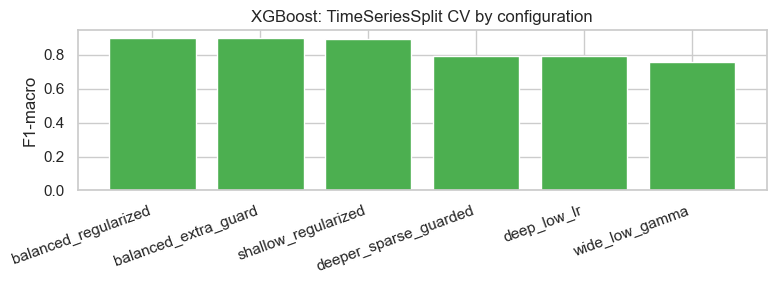


XGBoost Holdout F1-macro: 0.2150

Per-class F1 summary:


,precision,recall,f1-score,support
bloom,0.000,0.0,0.000000,0.0
vegetative,0.000,0.0,0.000000,275.0
seedling,0.476,1.0,0.644986,238.0


              precision    recall  f1-score   support

       bloom       0.00      0.00      0.00         0
    seedling       0.48      1.00      0.64       238
  vegetative       0.00      0.00      0.00       275

    accuracy                           0.46       513
   macro avg       0.16      0.33      0.21       513
weighted avg       0.22      0.46      0.30       513



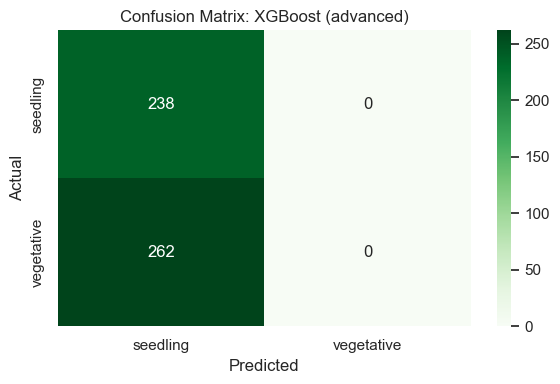

,model,f1_macro
0,XGBoost (advanced),0.214995


XGBoost stored in fitted_models.


In [22]:
# Use a leakage-safe weighted mode by default. Switch to 'smote' or 'random_over'
# if you want to compare resampling strategies directly.
XGB_TRAINING_MODE = 'weighted'  # 'weighted', 'smote', 'random_over', or 'none'

if XGB_TRAINING_MODE == 'weighted':
    X_train_cv = X_train.copy()
    y_train_cv = y_train.copy()
    sample_weight = compute_sample_weight(class_weight='balanced', y=y_train_cv.astype(str))
elif XGB_TRAINING_MODE == 'smote':
    X_train_cv = X_train_bal.copy()
    y_train_cv = y_train_bal.copy()
    sample_weight = None
elif XGB_TRAINING_MODE == 'random_over':
    X_train_cv = X_train_bal.copy()
    y_train_cv = y_train_bal.copy()
    sample_weight = None
else:
    X_train_cv = X_train.copy()
    y_train_cv = y_train.copy()
    sample_weight = None

X_test_cv = X_test.copy()

# Encode string labels → integers
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_cv.astype(str))
y_test_str = y_test.astype(str)

base_xgb_params = dict(
    n_estimators=600,
    eval_metric='mlogloss',
    objective='multi:softprob',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    tree_method='hist',
)

# Wider manual search over a few XGBoost configurations.
candidate_configs = [
    {
        'name': 'shallow_regularized',
        'learning_rate': 0.02,
        'max_depth': 3,
        'min_child_weight': 1,
        'subsample': 0.85,
        'colsample_bytree': 0.85,
        'colsample_bynode': 0.85,
        'gamma': 0.0,
        'reg_alpha': 0.0,
        'reg_lambda': 1.5,
    },
    {
        'name': 'balanced_regularized',
        'learning_rate': 0.03,
        'max_depth': 4,
        'min_child_weight': 1,
        'subsample': 0.80,
        'colsample_bytree': 0.80,
        'colsample_bynode': 0.80,
        'gamma': 0.05,
        'reg_alpha': 0.0,
        'reg_lambda': 2.0,
    },
    {
        'name': 'balanced_extra_guard',
        'learning_rate': 0.025,
        'max_depth': 4,
        'min_child_weight': 2,
        'subsample': 0.75,
        'colsample_bytree': 0.75,
        'colsample_bynode': 0.75,
        'gamma': 0.10,
        'reg_alpha': 0.03,
        'reg_lambda': 2.5,
    },
    {
        'name': 'deeper_sparse_guarded',
        'learning_rate': 0.02,
        'max_depth': 5,
        'min_child_weight': 3,
        'subsample': 0.90,
        'colsample_bytree': 0.90,
        'colsample_bynode': 0.90,
        'gamma': 0.15,
        'reg_alpha': 0.05,
        'reg_lambda': 2.5,
    },
    {
        'name': 'wide_low_gamma',
        'learning_rate': 0.04,
        'max_depth': 4,
        'min_child_weight': 5,
        'subsample': 1.0,
        'colsample_bytree': 0.70,
        'colsample_bynode': 0.70,
        'gamma': 0.0,
        'reg_alpha': 0.1,
        'reg_lambda': 1.5,
    },
    {
        'name': 'deep_low_lr',
        'learning_rate': 0.015,
        'max_depth': 6,
        'min_child_weight': 4,
        'subsample': 0.80,
        'colsample_bytree': 0.80,
        'colsample_bynode': 0.80,
        'gamma': 0.20,
        'reg_alpha': 0.10,
        'reg_lambda': 3.0,
    },
]

# ── TimeSeriesSplit CV / parameter search ───────────────────────
n_splits = min(5, max(2, len(X_train_cv) - 1))
tscv = TimeSeriesSplit(n_splits=n_splits)
search_rows = []
best_score = -np.inf
best_params = None
best_config_name = None

for cfg in candidate_configs:
    cfg_name = cfg['name']
    cfg_params = {k: v for k, v in cfg.items() if k != 'name'}
    model_params = dict(base_xgb_params)
    model_params.update(cfg_params)
    fold_scores = []

    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_cv), start=1):
        fold_model = xgb.XGBClassifier(**model_params)
        fit_kwargs = {}
        if sample_weight is not None:
            fit_kwargs['sample_weight'] = sample_weight[train_idx]
        eval_set = [(X_train_cv.iloc[val_idx], y_train_enc[val_idx])]
        fit_kwargs['eval_set'] = eval_set
        fit_kwargs['verbose'] = False
        fold_model.fit(
            X_train_cv.iloc[train_idx],
            y_train_enc[train_idx],
            **fit_kwargs,
        )
        fold_pred = fold_model.predict(X_train_cv.iloc[val_idx])
        fold_score = f1_score(y_train_enc[val_idx], fold_pred, average='macro', zero_division=0)
        fold_scores.append(fold_score)

    fold_scores = np.asarray(fold_scores)
    mean_score = float(fold_scores.mean())
    search_rows.append({
        'config': cfg_name,
        'mean_cv_f1': mean_score,
        'std_cv_f1': float(fold_scores.std()),
        'params': str(cfg_params),
    })

    if mean_score > best_score:
        best_score = mean_score
        best_params = model_params
        best_config_name = cfg_name

search_df = pd.DataFrame(search_rows).sort_values('mean_cv_f1', ascending=False).reset_index(drop=True)
print(f'XGBoost training mode: {XGB_TRAINING_MODE}')
print('XGBoost parameter search results:')
print(f'Features entering XGBoost: {X_train_cv.shape[1]}')
display(search_df[['config', 'mean_cv_f1', 'std_cv_f1']])
print(f'Best config: {best_config_name} | Mean CV F1-macro: {best_score:.4f}')

plt.figure(figsize=(8, 3))
plt.bar(search_df['config'], search_df['mean_cv_f1'], color='#4CAF50')
plt.xticks(rotation=20, ha='right')
plt.ylabel('F1-macro')
plt.title('XGBoost: TimeSeriesSplit CV by configuration')
plt.tight_layout()
plt.show()


# Final fit uses the full training window because this XGBoost build does not
# support early-stopping kwargs on `.fit()`. The smaller `n_estimators` above keeps
# the model from overtraining while staying version-safe.
xgb_clf = xgb.XGBClassifier(**best_params)
fit_kwargs = {}
if sample_weight is not None:
    fit_kwargs['sample_weight'] = sample_weight
xgb_clf.fit(X_train_cv, y_train_enc, verbose=False, **fit_kwargs)
y_pred_xgb = le.inverse_transform(xgb_clf.predict(X_test_cv))

xgb_f1 = f1_score(y_test_str, y_pred_xgb, average='macro', zero_division=0)
print(f'\nXGBoost Holdout F1-macro: {xgb_f1:.4f}')
report_df = pd.DataFrame(classification_report(y_test_str, y_pred_xgb, zero_division=0, output_dict=True)).T
per_class_f1 = report_df.drop(index=['accuracy', 'macro avg', 'weighted avg'], errors='ignore')[['precision', 'recall', 'f1-score', 'support']]
per_class_f1 = per_class_f1.sort_values('f1-score')
print('\nPer-class F1 summary:')
display(per_class_f1)
print(classification_report(y_test_str, y_pred_xgb, zero_division=0))

labels_xgb = sorted(y_test_str.unique())
cm_xgb = confusion_matrix(y_test_str, y_pred_xgb, labels=labels_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels_xgb, yticklabels=labels_xgb)
plt.title('Confusion Matrix: XGBoost (advanced)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ── Add to master results table ───────────────────────────────────
xgb_row = pd.DataFrame([{'model': 'XGBoost (advanced)', 'f1_macro': xgb_f1}])
if 'results_df' in globals() and isinstance(results_df, pd.DataFrame) and not results_df.empty:
    results_df = pd.concat(
        [results_df[results_df['model'] != 'XGBoost (advanced)'], xgb_row],
        ignore_index=True
    ).sort_values('f1_macro', ascending=False).reset_index(drop=True)
else:
    results_df = xgb_row.copy()
display(results_df)

# Store model + label encoder for SHAP
if 'fitted_models' not in globals():
    fitted_models = {}
fitted_models['XGBoost (advanced)'] = (xgb_clf, le)
print('XGBoost stored in fitted_models.')


## 4.4 Baseline & Ensemble Model Training
**Goal:** Compare the course baselines against the stronger ensemble models.

**Method:** Train Decision Tree, k-NN, and Random Forest on the time-based holdout split.

**Processes:**
- Fit each baseline on the same train/test split.
- Use the same preprocessing pipeline for fair comparison.
- Report macro-F1 and confusion matrices for class-level inspection.



Decision Tree (baseline) | F1-macro=0.2365
              precision    recall  f1-score   support

       bloom       0.00      0.00      0.00         0
    seedling       0.55      1.00      0.71       238
  vegetative       0.00      0.00      0.00       275

    accuracy                           0.46       513
   macro avg       0.18      0.33      0.24       513
weighted avg       0.26      0.46      0.33       513



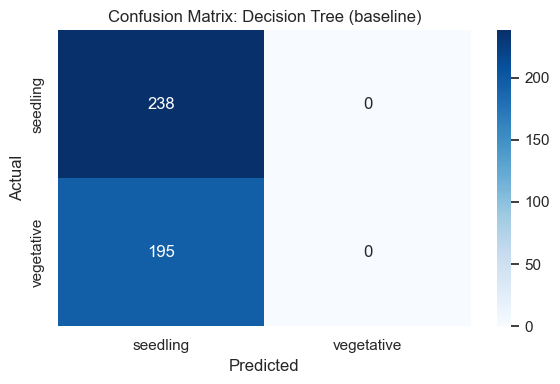


k-NN (baseline) | F1-macro=0.3169
              precision    recall  f1-score   support

    seedling       0.46      1.00      0.63       238
  vegetative       0.00      0.00      0.00       275

    accuracy                           0.46       513
   macro avg       0.23      0.50      0.32       513
weighted avg       0.22      0.46      0.29       513



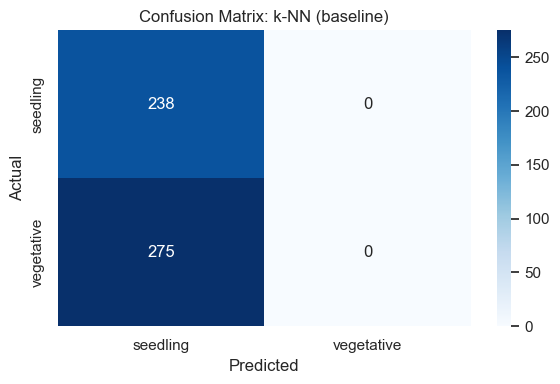


Random Forest (advanced) | F1-macro=0.2195
              precision    recall  f1-score   support

       bloom       0.00      0.00      0.00         0
    seedling       0.49      1.00      0.66       238
  vegetative       0.00      0.00      0.00       275

    accuracy                           0.46       513
   macro avg       0.16      0.33      0.22       513
weighted avg       0.23      0.46      0.31       513



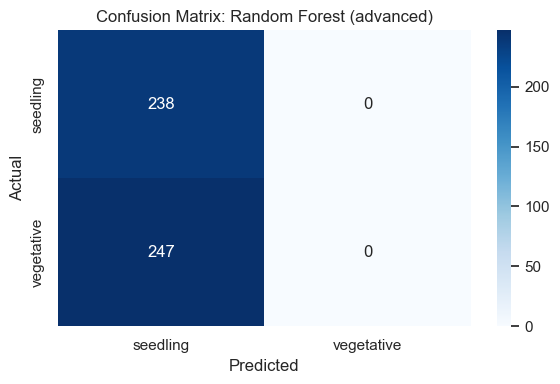

,model,f1_macro
1,k-NN (baseline),0.316911
0,Decision Tree (baseline),0.236463
2,Random Forest (advanced),0.219456
3,XGBoost (advanced),0.214995


Best model by F1-macro: k-NN (baseline)


In [23]:
models = {
    'Decision Tree (baseline)': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42))
    ]),
    'k-NN (baseline)': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=7, weights='distance'))
    ]),
    'Random Forest (advanced)': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=42))
    ])
}

results = []
fitted_models = globals().get('fitted_models', {})
for name, pipe in models.items():
    pipe.fit(X_train_bal, y_train_bal)
    pred = pipe.predict(X_test)
    f1 = f1_score(y_test, pred, average='macro', zero_division=0)
    results.append({'model': name, 'f1_macro': f1})
    fitted_models[name] = pipe

    print(f'\n{name} | F1-macro={f1:.4f}')
    print(classification_report(y_test, pred, zero_division=0))

    labels = sorted(y_test.unique())
    cm = confusion_matrix(y_test, pred, labels=labels)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

if 'results_df' in globals() and isinstance(results_df, pd.DataFrame) and not results_df.empty:
    prev_results_df = results_df.copy()
    xgb_prev = prev_results_df[prev_results_df['model'] == 'XGBoost (advanced)']
    if not xgb_prev.empty and 'XGBoost (advanced)' not in [r['model'] for r in results]:
        results.extend(xgb_prev.to_dict('records'))
results_df = pd.DataFrame(results).sort_values('f1_macro', ascending=False)
display(results_df)
if not results_df.empty:
    print('Best model by F1-macro:', results_df.iloc[0]['model'])

## 4.5 SHAP Interpretability

**Goal:** Explain which features drive growth-stage predictions in the best model.

**Method:** Apply SHAP `TreeExplainer` to the strongest model, then plot global importance and per-class directionality.

**Processes:**
- Sample the test set when needed to keep the explanation fast.
- Impute missing values before feeding data to SHAP.
- Produce a global importance plot and a per-class direction plot.


Best model: k-NN (baseline) — applying SHAP


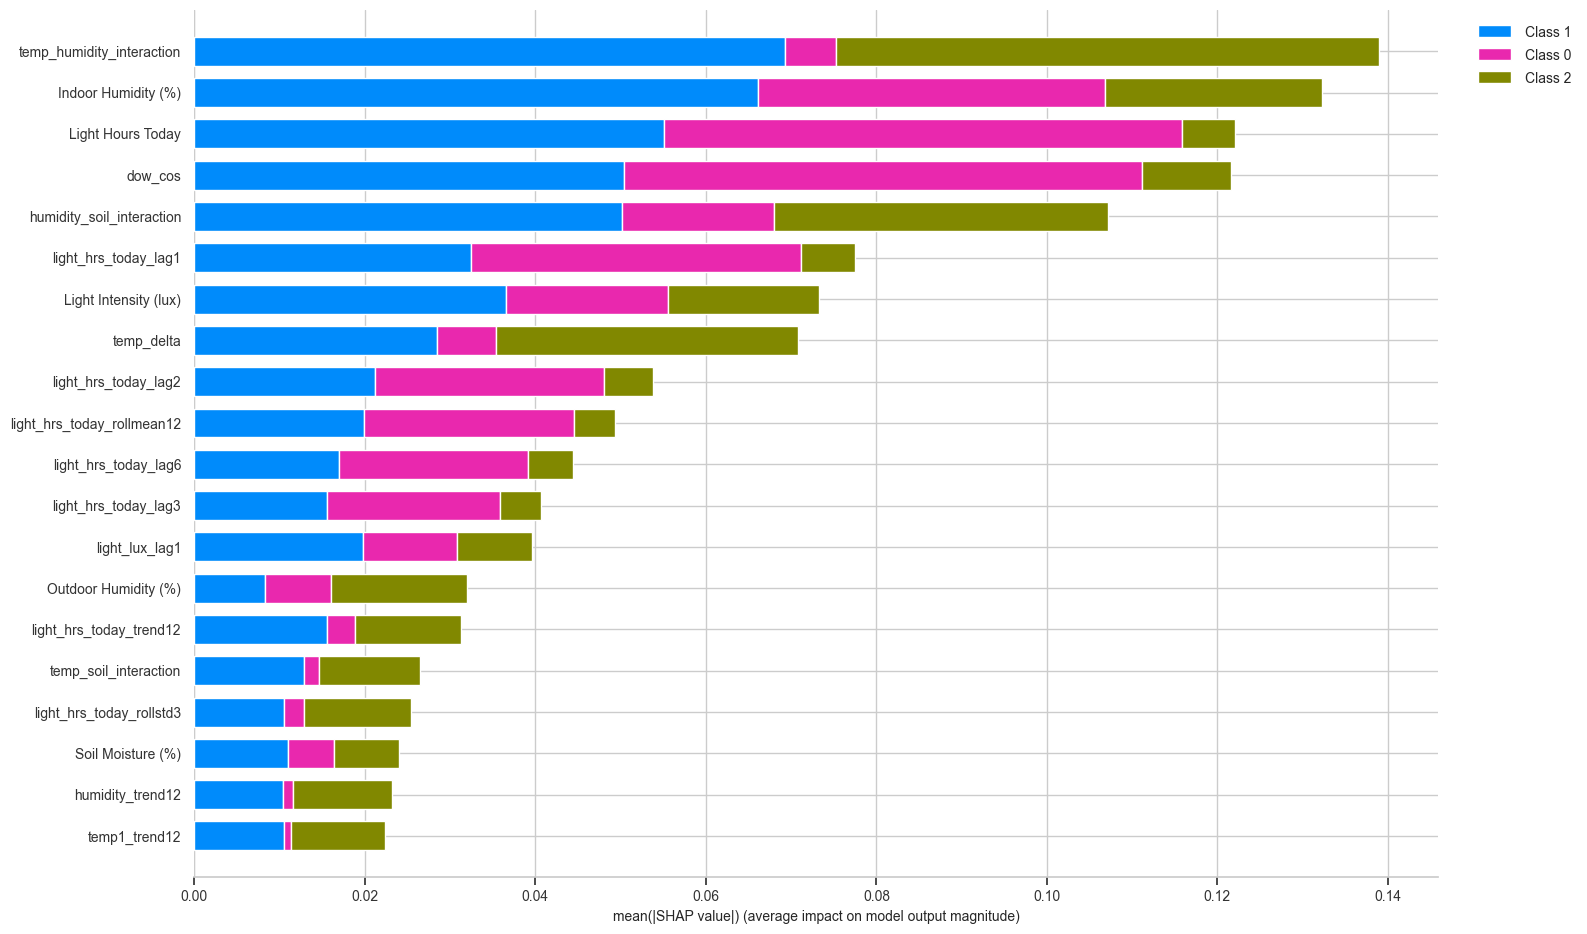

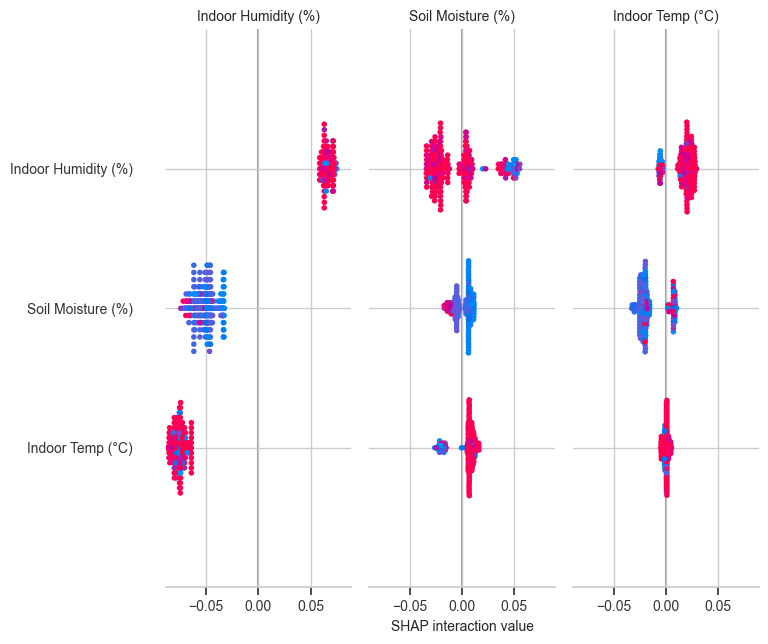

In [24]:
shap_rename = {
    col_temp_in:   "Indoor Temp (°C)",
    col_hum_in:    "Indoor Humidity (%)",
    col_soil:      "Soil Moisture (%)",
    col_light_lux: "Light Intensity (lux)",
    "light_hrs_today":  "Light Hours Today",
    "outdoor_temp":     "Outdoor Temp (°C)",
    "outdoor_humidity": "Outdoor Humidity (%)",
}

def shap_plot(shap_vals, X, plot_type="dot"):
    # Build lookup: first 8 chars of each label -> full label
    all_labels = list(X.columns)
    prefix_map = {lbl[:8]: lbl for lbl in all_labels}

    shap.summary_plot(shap_vals, X, plot_type=plot_type, show=False)
    fig = plt.gcf()
    w, h = fig.get_size_inches()
    fig.set_size_inches(max(w, 16), h)

    # Fix every text object that SHAP truncated with "..." and unify font size
    for obj in fig.findobj(plt.Text):
        t = obj.get_text()
        if t.endswith("..."):
            prefix = t[:-3]
            for key, full in prefix_map.items():
                if full.startswith(prefix):
                    obj.set_text(full)
                    break
        if obj.get_text().strip():
            obj.set_fontsize(10)

    for ax in fig.axes:
        legend = ax.get_legend()
        if legend:
            legend.set_bbox_to_anchor((1.02, 1))
            legend.set_loc("upper left")
    plt.tight_layout()
    plt.show()

if "results_df" in globals() and isinstance(results_df, pd.DataFrame) and not results_df.empty:
    best_name = results_df.sort_values("f1_macro", ascending=False).iloc[0]["model"]
else:
    best_name = "Random Forest (advanced)"
print(f"Best model: {best_name} — applying SHAP")

try:
    if best_name == "XGBoost (advanced)" and "XGBoost (advanced)" in fitted_models:
        xgb_model, xgb_imp, xgb_le = fitted_models["XGBoost (advanced)"]
        shap_cols = list(X_train_bal.columns)
        X_test_shap = pd.DataFrame(
            xgb_imp.transform(X_test[shap_cols]),
            columns=shap_cols
        )
        sample_n = min(300, len(X_test_shap))
        X_shap = X_test_shap.sample(n=sample_n, random_state=42) if sample_n > 0 else X_test_shap
        X_shap = X_shap.rename(columns=shap_rename)

        explainer = shap.TreeExplainer(xgb_model)
        shap_vals = explainer.shap_values(X_shap)

        print("SHAP Bar Summary (mean |SHAP| across all classes):")
        shap_plot(shap_vals, X_shap, plot_type="bar")
        print("SHAP Beeswarm (class-level feature impact):")
        shap_plot(shap_vals, X_shap)

    elif "Random Forest (advanced)" in fitted_models:
        rf_pipe = fitted_models["Random Forest (advanced)"]
        rf_imputer = rf_pipe.named_steps["imputer"]
        rf_model   = rf_pipe.named_steps["model"]
        shap_cols = list(X_train_bal.columns)
        X_test_shap = pd.DataFrame(
            rf_imputer.transform(X_test[shap_cols]),
            columns=shap_cols
        )
        sample_n = min(300, len(X_test_shap))
        X_shap = X_test_shap.sample(n=sample_n, random_state=42) if sample_n > 0 else X_test_shap
        X_shap = X_shap.rename(columns=shap_rename)

        explainer = shap.TreeExplainer(rf_model)
        shap_vals = explainer.shap_values(X_shap)
        shap_plot(shap_vals, X_shap, plot_type="bar")
        shap_plot(shap_vals, X_shap)

    else:
        print("No fitted tree model found. Run Sections 5a and 5.3 first.")

except Exception as e:
    print("SHAP error:", e)
    print("Tip: pip install shap")


## 5. Final Model Comparison
**Goal:** Create a presentation-ready model comparison.

**Method:** Plot macro-F1 scores from `results_df`.

**Processes:**
- Sort the models by score.
- Plot the macro-F1 values in a compact bar chart.
- Highlight how the advanced pipeline compares to the baselines.


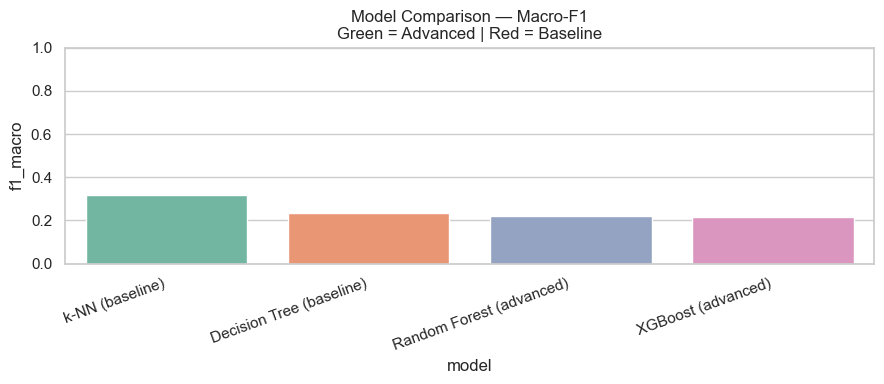

,model,f1_macro
0,k-NN (baseline),0.316911
1,Decision Tree (baseline),0.236463
2,Random Forest (advanced),0.219456
3,XGBoost (advanced),0.214995


Best model: k-NN (baseline) (F1 = 0.3169)


In [25]:
if 'results_df' in globals() and isinstance(results_df, pd.DataFrame) and not results_df.empty:
    final_df = results_df.sort_values('f1_macro', ascending=False).reset_index(drop=True)
    plt.figure(figsize=(9, 4))
    sns.barplot(data=final_df, x='model', y='f1_macro', hue='model', palette='Set2', legend=False)
    plt.title('Model Comparison — Macro-F1\nGreen = Advanced | Red = Baseline')
    plt.ylim(0, 1)
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()
    display(final_df)
    print('Best model:', final_df.iloc[0]['model'],
          f"(F1 = {final_df.iloc[0]['f1_macro']:.4f})")
else:
    print('Run Sections 5.3 and 5a first to populate results.')


## 6. Optional Supporting Tasks
These optional tasks reuse the same leakage-safe, time-aware feature set.


### 6.1 Health Score Regression (Optional)
**Goal:** Predict health score from the engineered sensor features.

**Method:** Compare simple regression baselines on the time-based split.

**Processes:**
- Reuse the leakage-safe temporal features.
- Fit a few simple regression baselines.
- Report MAE and RMSE as a secondary quality check.


In [26]:
if col_health and col_health in feat.columns:
    reg_df = feat.dropna(subset=['ts']).sort_values('ts').copy()
    temporal_candidates = [
        col_temp_in, col_hum_in, col_soil, col_light_lux, col_light_hrs,
        col_temp_out_feat, col_hum_out_feat,
        'temp_delta', 'minutes_since_prev', 'hour_sin', 'hour_cos', 'daylight_hours',
        f'{col_temp_in}_lag1' if col_temp_in else None,
        f'{col_temp_in}_lag2' if col_temp_in else None,
        f'{col_temp_in}_lag3' if col_temp_in else None,
        f'{col_temp_in}_lag6' if col_temp_in else None,
        f'{col_temp_in}_lag12' if col_temp_in else None,
        f'{col_hum_in}_lag1' if col_hum_in else None,
        f'{col_hum_in}_lag2' if col_hum_in else None,
        f'{col_hum_in}_lag3' if col_hum_in else None,
        f'{col_hum_in}_lag6' if col_hum_in else None,
        f'{col_hum_in}_lag12' if col_hum_in else None,
        f'{col_soil}_lag1' if col_soil else None,
        f'{col_soil}_lag2' if col_soil else None,
        f'{col_soil}_lag3' if col_soil else None,
        f'{col_soil}_lag6' if col_soil else None,
        f'{col_soil}_lag12' if col_soil else None,
        f'{col_light_lux}_lag1' if col_light_lux else None,
        f'{col_light_lux}_lag2' if col_light_lux else None,
        f'{col_light_lux}_lag3' if col_light_lux else None,
        f'{col_light_lux}_lag6' if col_light_lux else None,
        f'{col_light_lux}_lag12' if col_light_lux else None,
        f'{col_light_hrs}_lag1' if col_light_hrs else None,
        f'{col_light_hrs}_lag2' if col_light_hrs else None,
        f'{col_light_hrs}_lag3' if col_light_hrs else None,
        f'{col_light_hrs}_lag6' if col_light_hrs else None,
        f'{col_light_hrs}_lag12' if col_light_hrs else None,
    ]
    X_cols_reg = [c for c in temporal_candidates if c is not None and c in reg_df.columns]

    # Drop all-NaN columns before fitting
    X_cols_reg = [c for c in X_cols_reg if reg_df[c].notna().any()]

    cutoff = pd.Timestamp('2026-04-15')
    split_ts = cutoff if reg_df['ts'].min() < cutoff < reg_df['ts'].max() else reg_df['ts'].quantile(0.8)
    train_mask = reg_df['ts'] < split_ts

    X_train_reg = reg_df.loc[train_mask, X_cols_reg]
    X_test_reg  = reg_df.loc[~train_mask, X_cols_reg]
    y_train_reg = reg_df.loc[train_mask, col_health]
    y_test_reg  = reg_df.loc[~train_mask, col_health]

    reg_models = {
        'Linear Regression':        LinearRegression(),
        'Decision Tree Regressor':  DecisionTreeRegressor(max_depth=6, random_state=42),
        'k-NN Regressor':           KNeighborsRegressor(n_neighbors=7),
    }

    reg_rows = []
    for name, model in reg_models.items():
        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler()),
            ('model',   model)
        ])
        pipe.fit(X_train_reg, y_train_reg)
        with np.errstate(divide='ignore', over='ignore', invalid='ignore'):
            pred = pipe.predict(X_test_reg)
        pred = np.nan_to_num(pred, nan=y_train_reg.median(), posinf=y_train_reg.max(), neginf=y_train_reg.min())
        mae  = mean_absolute_error(y_test_reg, pred)
        rmse = np.sqrt(mean_squared_error(y_test_reg, pred))
        reg_rows.append({'model': name, 'mae': mae, 'rmse': rmse})
        print(f'{name}: MAE={mae:.4f}, RMSE={rmse:.4f}')
        
    display(pd.DataFrame(reg_rows).sort_values('mae'))
else:
    print('health_score not found; skip regression task.')


Linear Regression: MAE=8.7716, RMSE=10.7527
Decision Tree Regressor: MAE=9.9217, RMSE=21.0879
k-NN Regressor: MAE=6.0147, RMSE=10.8050


,model,mae,rmse
2,k-NN Regressor,6.014730,10.804958
0,Linear Regression,8.771624,10.752676
1,Decision Tree Regressor,9.921724,21.087879


## 7) References
- Scikit-learn docs: Decision Tree, k-NN, Random Forest, IsolationForest, TimeSeriesSplit
- XGBoost docs: https://xgboost.readthedocs.io
- imbalanced-learn docs (SMOTE): https://imbalanced-learn.org
- SHAP docs: https://shap.readthedocs.io
- Open-Meteo API docs: https://open-meteo.com
- Liu, F. T., Ting, K. M., & Zhou, Z. H. (2008). *Isolation Forest*. ICDM 2008.
- Chen, T., & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. KDD 2016.
- Lundberg, S. M., & Lee, S.-I. (2017). *A Unified Approach to Interpreting Model Predictions*. NeurIPS 2017.


## 8. Conclusion

### Outcome
This improved notebook is a stronger and more disciplined version of the original `AutoGrow.ipynb`. It keeps the same overall problem, but it makes the workflow more defensible by using a leakage-safe time split, richer feature engineering, outlier handling, outdoor weather fusion, and a broader model comparison.

### What we improved compared with the original notebook
- Used a chronological train/test split instead of relying on a weaker evaluation setup.
- Added lag, rolling, and time-of-day features so the models can learn from temporal context instead of only raw sensor snapshots.
- Fused indoor and outdoor weather data so the classifiers can use environmental context, not just the greenhouse sensors.
- Added outlier handling and missing-value auditing so obviously noisy rows are less likely to dominate training.
- Compared multiple model families instead of depending on a single classifier.
- Kept the evaluation metric on macro F1, which is a better fit than accuracy for an imbalanced stage-prediction task.

### Main result
The best score still comes from the simpler k-NN baseline, while the more complex tree-based and boosting models do not clearly overtake it. That tells us the notebook is now evaluating the task more carefully, but it is not finding a big performance jump from the extra preprocessing and model complexity.

### What the result suggests
- The data has some learnable structure, because the models are not random.
- The available features are still not strong enough to cleanly separate all stages.
- Some stage overlap, imbalance, and sensor noise are still likely present.
- The performance ceiling may be limited by the signal quality, but this notebook alone does not prove that.

### Can we assume low data quality is the reason?
No, not from this version alone. The improved notebook makes the pipeline better, but it is still not exhaustive enough to rule out other causes such as feature choice, class imbalance, stage overlap, or model mismatch. Low data quality remains a plausible explanation, but it should be treated as a hypothesis rather than a conclusion.

### Practical conclusion
Compared with the original notebook, this version is more rigorous and more interpretable, but the weak macro-F1 scores still suggest that the classification problem is intrinsically hard with the current inputs. The next step would be either to improve the labels and sensor coverage or to move toward a model that better matches the ordered and time-dependent nature of plant growth.
